# Quantitative analysis for the thesis: tail sensitivity (Vega) and "barbell" portfolios

This notebook implements the thesis framework to measure the sensitivity of distribution tails (left `V` and right `W`) of a portfolio to changes in the reference threshold Omega, the semi-deviation `s`, and the strike level `K`/`L`. The framework is first applied to the S&P 500 index (with and without put protection, and under a stress scenario), then to a set of "barbell" portfolios (85/90/95% in the risk-free asset) built on large-cap stocks, cryptocurrencies, and small-cap stocks.

**Library imports**: loads `yfinance` for market data, `numpy`/`pandas` for numerical computation, `matplotlib` for plotting, `cvxpy` for portfolio optimization, and `statsmodels`'s ECDF for empirical distribution functions.

In [1]:
# Libraries and packages
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from statsmodels.distributions.empirical_distribution import ECDF 

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

/Users/gabri/venvs/tesi-magistrale/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Defines the thesis's core mathematical functions: the left semi-deviation `s-` (mean of the shortfalls below threshold Omega) and the right semi-deviation `s+`, the scale factor `lambda` that rescales the empirical distribution relative to a baseline, the truncated tail measure `xi(K, s-)` (area of the CDF truncated at K) and its sensitivity `Vega` with respect to changes in `s`, plus the first and second derivatives of Vega with respect to `s-` and `K`. These are the building blocks used throughout the rest of the analysis — no direct output here, only definitions.

In [2]:
#############################################################################################
# FUNCTIONS FOR s^-, s^+, Xi(S^-,K), Xi(S^+,L) V and W and various derivatives
#############################################################################################

def s_minus(data, Omega):
    arr = np.asarray(data)
    return np.mean(np.maximum(Omega - arr, 0.0))

def lambda_from_s_empirical(s_empirical, s_baseline, eps=0):
    return s_empirical / (s_baseline + eps)

def xi_K(data, lambda_s, Omega, K):
    arr = np.asarray(data)
    scaled_data = Omega + lambda_s * (arr - Omega)
    x_sorted = np.sort(scaled_data)
    n = len(x_sorted)
    F_K = np.sum(x_sorted <= K) / n

    mask = x_sorted <= K
    x_below = x_sorted[mask]
    m = len(x_below)

    if m == 0:
        integral = 0.0
    elif m == 1:
        integral = 0.0
    else:
        widths = np.diff(x_below)
        heights = np.arange(1, m) / n
        integral = np.sum(widths * heights)
    if m > 0:
        integral += (K - x_below[-1]) * (m / n)
    return (Omega - K) * F_K + integral

def xi_K_on_baseline(baseline_data, lambda_s, Omega, K):
    return xi_K(baseline_data, lambda_s, Omega, K)

def vega_tail_baseline(baseline_data, s_target, s_baseline, Omega, K, Delta_s=1e-4):
    lam_plus  = lambda_from_s_empirical(s_target + Delta_s, s_baseline)
    lam_minus = lambda_from_s_empirical(max(s_target - Delta_s, 0.0), s_baseline)
    xi_plus  = xi_K_on_baseline(baseline_data, lam_plus, Omega, K)
    xi_minus = xi_K_on_baseline(baseline_data, lam_minus, Omega, K)
    V = (xi_plus - xi_minus) / (2 * Delta_s)
    return V

def vega_derivative_s_minus(data, s_minus_target, s_baseline, Omega, K, Delta_s):
    lam_plus  = lambda_from_s_empirical(s_minus_target + Delta_s, s_baseline)
    lam_0     = lambda_from_s_empirical(s_minus_target, s_baseline)
    lam_minus = lambda_from_s_empirical(max(s_minus_target - Delta_s, 0.0), s_baseline)
    xi_plus  = xi_K_on_baseline(data, lam_plus, Omega, K)
    xi_0     = xi_K_on_baseline(data, lam_0, Omega, K)
    xi_minus = xi_K_on_baseline(data, lam_minus, Omega, K)
    sec = (xi_plus - 2.0 * xi_0 + xi_minus) / (Delta_s ** 2)
    return sec

def vega_derivative_k(data, s_minus_target, Omega, K, Delta_K=1e-4):
    V_plus = vega_tail_baseline(data, s_minus_target, s_minus_target, Omega, K + Delta_K, Delta_K)
    V_minus = vega_tail_baseline(data, s_minus_target, s_minus_target, Omega, K - Delta_K, Delta_K)
    derivative = (V_plus - V_minus) / (2 * Delta_K)
    return derivative

def calculate_vega_vs_k_values(data, s_minus_target, Omega, K_vals, Delta_s=1e-4):
    vega_vals = []
    for K in K_vals:
        vega = vega_tail_baseline(data, s_minus_target, s_minus_target, Omega, K, Delta_s)
        vega_vals.append(vega)
    return np.array(vega_vals)

def integrated_vega_vs_k_discrete(data, s_minus_target, Omega, K_min, K_max, Delta_s=1e-4, n_points=500):
    K_vals = np.linspace(K_min, K_max, n_points)
    vega_vals = calculate_vega_vs_k_values(data, s_minus_target, Omega, K_vals, Delta_s)
    integral = np.trapezoid(vega_vals, K_vals)  # pyright: ignore[reportAttributeAccessIssue] — numpy 2.0.2's stub omits trapezoid despite it existing at runtime
    return integral

def calculate_vega_vs_s_minus(data, s_minus_vals, Omega, K, Delta_s=1e-4):
    vega_vals = []
    for s_minus in s_minus_vals:
        vega = vega_tail_baseline(data, s_minus, s_minus, Omega, K, Delta_s)
        vega_vals.append(vega)
    return np.array(vega_vals)

def integrated_vega_vs_s_minus(data, Omega, K, s_min, s_max, Delta_s=1e-4, n_points=500):
    s_minus_vals = np.linspace(s_min, s_max, n_points)
    vega_vals = calculate_vega_vs_s_minus(data, s_minus_vals, Omega, K, Delta_s)
    integral = np.trapezoid(vega_vals, s_minus_vals)  # pyright: ignore[reportAttributeAccessIssue] — numpy 2.0.2's stub omits trapezoid despite it existing at runtime
    return integral

def s_plus(data, Omega):
    arr = np.asarray(data)
    return np.mean(np.maximum(arr - Omega, 0.0))

def lambda_from_s_plus_empirical(s_empirical, s_baseline, eps=0):
    return s_empirical / (s_baseline + eps)

def xi_plus(data, lambda_s, Omega, L, H):
    data = np.asarray(data)
    scaled_data = Omega + lambda_s * (data - Omega)
    x_sorted = np.sort(scaled_data)
    ecdf = ECDF(x_sorted)

    mask = (x_sorted >= L) & (x_sorted <= H)
    x_in_range = x_sorted[mask]
    
    if len(x_in_range) == 0:
        return 0.0
    
    surv = 1 - ecdf(x_in_range)
    
    diff = np.diff(x_in_range)

    heights = surv[:-1]
    
    integral = np.sum(diff * (x_in_range[:-1] - Omega) * heights)
    
    return integral

def xi_plus_on_baseline(baseline_data, lambda_s, Omega, L, H):
    return xi_plus(baseline_data, lambda_s, Omega, L, H)
   
def w_vega_right_baseline(baseline_data, s_target, s_baseline, Omega, L, H, Delta_s=1e-4):
    lam_plus = lambda_from_s_plus_empirical(s_target + Delta_s, s_baseline)
    lam_minus = lambda_from_s_plus_empirical(max(s_target - Delta_s, 0.0), s_baseline)
    xi_plus_val = xi_plus_on_baseline(baseline_data, lam_plus, Omega, L, H)
    xi_minus_val = xi_plus_on_baseline(baseline_data, lam_minus, Omega, L, H)
    W = (xi_plus_val - xi_minus_val) / (2 * Delta_s)
    return W



Defines three standard risk metrics used as a benchmark: **max drawdown** (largest peak-to-trough loss), the **historical 5% VaR** (quantile of the return distribution), and the **5% CVaR/Expected Shortfall** (average of the returns beyond the VaR). Again, no output, only function definitions.

In [3]:
#############################################################################################
# FUNCTIONS FOR STANDARD RISK METRICS
#############################################################################################

# Max drawdown
def max_drawdown(x):
    cum_returns = (1 + x).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

# Historical Value at Risk 5%
def var_5(x, alpha=0.05):
    return np.quantile(x, alpha)

# CVaR (Expected Shortfall) 
def cvar_historical(returns, alpha=0.05):
    x = returns.dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    if len(tail) == 0:
        return np.nan
    return tail.mean() 

Defines the portfolio optimization infrastructure using `cvxpy`: `solve_portfolio` solves a convex optimization problem given constraints and an objective function (SCS solver), normalizing the weights and rescaling them for the weight allocated to the risky sleeve; `objective_minvar`/`constraints_minvar` define the minimum-variance problem (minimize w'Sigma w subject to weights summing to 1 and a minimum weight per asset).

In [4]:
#############################################################################################
# FUNCTIONS FOR PORTFOLIO OPTIMIZATION 
#############################################################################################

# Portfolio optimization functions
def solve_portfolio(constraints_func, objective_func):
    w = cp.Variable(n_assets)
    prob = cp.Problem(objective_func(w), constraints_func(w))
    prob.solve(solver=cp.SCS)
    if w.value is None:
        print("Problem not solved. Weights = NaN")
        return pd.Series(np.nan, index=assets_returns.columns)
    w_val = np.array(w.value)
    w_val = w_val / w_val.sum()  # normalize for safety
    return pd.Series(w.value * risk_asset_weight, index=assets_returns.columns)

# Minimum variance
def objective_minvar(w): return cp.Minimize(cp.quad_form(w, Sigma))
def constraints_minvar(w): return [cp.sum(w) == 1, w >= min_weight_per_asset]

**Data download**: downloads the weekly historical series of the S&P 500 index (`^GSPC`) from 1950 to 2025 via `yfinance`, and computes weekly log-returns (`log_ret`) as the basis for all subsequent V/W analysis on the index.

In [5]:
#############################################################################################
# Data downloading and analysis
#############################################################################################

# Download weekly S&P 500 data 
ticker = yf.Ticker("^GSPC") # change ticker to change asset
data = ticker.history(start="1950-01-01", end="2025-01-01", interval="1wk") # time period and weekly returns
close = data['Close']

# Calculate log returns
log_ret = pd.Series(np.log(close / close.shift(1)), index=close.index).dropna()

Builds the hedged portfolio with a **protective put**: strike at 97% of the price (`strike_ratio=0.97`), premium of 0.02% of the price per period. Computes the put's payoff, the hedged portfolio's final value, and the corresponding log-returns (`log_ret_with_put`), to be compared against the unhedged version.

In [6]:
# Put Parameters
strike_ratio = 0.97  # Modified to 1 for full protection

premium_ratio = 0.0002  # Modify here to include a premium

# Calculation for hedged portfolio log returns
strike = strike_ratio * close
premium_put = premium_ratio * close

payoff_put = np.maximum(strike - close.shift(-1), 0)
final_with_put = close.shift(-1) + payoff_put - premium_put
final_with_put = final_with_put.dropna()

log_ret_with_put = np.log(final_with_put / close.iloc[:-1].values)
log_ret_with_put = pd.Series(log_ret_with_put, index=final_with_put.index)

Simulates a **stress scenario**: appends a sequence of 12 sharply negative weekly shocks (from -5% to -30%) to the tail of the historical series, then recomputes log-returns and the hedged portfolio for the stressed scenario as well (`log_ret_stress`, `log_ret_with_put_stress`). The printed output shows the resulting series: 3,925 observations, from 1950-01-01 to 2025-03-16.

In [7]:
# Stress Test
# Calculation of log returns after stress test
extreme_moves = [-0.05, -0.3, -0.2, -0.1, -0.2, -0.3,-0.05, -0.3, -0.2, -0.1, -0.2, -0.3]
last_price = close.iloc[-1]
new_prices = [last_price * (1 + extreme_moves[0])]
for r in extreme_moves[1:]:
    new_prices.append(new_prices[-1] * (1 + r))
new_dates = [data.index[-1] + pd.Timedelta(weeks=i) for i in range(1, len(new_prices) + 1)]
data_ext = pd.DataFrame({'Close': new_prices}, index=new_dates)
data_stress = pd.concat([data, data_ext])

close_stress = data_stress['Close']
log_ret_stress = pd.Series(np.log(close_stress / close_stress.shift(1)), index=close_stress.index).dropna()

strike_stress = strike_ratio * close_stress
payoff_put_stress = np.maximum(strike_stress - close_stress.shift(-1), 0)
premium_put_stress = premium_ratio * close_stress

final_with_put_stress = close_stress.shift(-1) + payoff_put_stress - premium_put_stress
final_with_put_stress = final_with_put_stress.dropna()
log_ret_with_put_stress = np.log(final_with_put_stress / close_stress.iloc[:-1].values)
log_ret_with_put_stress = pd.Series(log_ret_with_put_stress, index=final_with_put_stress.index)

print(log_ret_with_put_stress)



1950-01-01 00:00:00-05:00   -0.026289
1950-01-08 00:00:00-05:00    0.017071
1950-01-15 00:00:00-05:00   -0.002565
1950-01-22 00:00:00-05:00    0.026084
1950-01-29 00:00:00-05:00   -0.008304
                               ...   
2025-02-16 00:00:00-05:00   -0.030665
2025-02-23 00:00:00-05:00   -0.030665
2025-03-02 00:00:00-05:00   -0.030665
2025-03-09 00:00:00-05:00   -0.030665
2025-03-16 01:00:00-04:00   -0.030665
Name: Close, Length: 3925, dtype: float64


Summary table of mean, standard deviation, variance, and 5% quantile for the four series. The put meaningfully reduces the left tail: the 5% quantile moves from **-3.19%** (unhedged original) to **-3.07%** (with put), and under the stress scenario the put maintains the same protection (**-3.07%** instead of -3.29% without hedging) — the hedge works both in normal conditions and under stress.

In [8]:
# Summary stats function
def summary_stats(series):
    return {
        'Mean': series.mean(),
        'Std': series.std(),
        'Variance': series.var(),
        'Quantile_0.05': series.quantile(0.05)
    }

# Create summary DataFrame
df_summ = pd.DataFrame([
    summary_stats(log_ret),
    summary_stats(log_ret_with_put),
    summary_stats(log_ret_stress),
    summary_stats(log_ret_with_put_stress)
],
    index=['Orig_NonProt', 'Orig_Put', 'Stress_NonProt', 'Stress_Put']
)

print(df_summ)



                    Mean       Std  Variance  Quantile_0.05
Orig_NonProt    0.001493  0.021153  0.000447      -0.031880
Orig_Put        0.002262  0.018486  0.000342      -0.030665
Stress_NonProt  0.000817  0.025201  0.000635      -0.032903
Stress_Put      0.002161  0.018547  0.000344      -0.030665


Defines the `plot_pdf_cdf` function, which draws, side by side, the density histogram (empirical PDF) and the empirical cumulative distribution function (ECDF), highlighting with a colored area the probability mass below the threshold Omega=0.

In [9]:
# Empirical distribution plots
def plot_pdf_cdf(returns, title_pdf, title_cdf):
    x = np.sort(returns)
    ecdf = ECDF(returns)
    y = ecdf(x)

    Omega = 0.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # PDF (normalized histogram)
    axes[0].hist(returns, bins=50, density=True, alpha=0.6,
                 color='steelblue', edgecolor="black")
    axes[0].set_title(title_pdf)
    axes[0].set_xlabel("Log Return")
    axes[0].set_ylabel("Density")

    # CDF (ECDF)
    axes[1].step(x, y, where="post", color="blue")
    axes[1].set_title(title_cdf)
    axes[1].set_xlabel("Log Return")
    axes[1].set_ylabel("P(R ≤ r)")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # Highlight area under Omega = 0 in the CDF using fill_between
    mask = x <= Omega
    if np.any(mask):
        # For fill_between, extract x and y up to Omega included
        x_fill = np.concatenate((x[mask], [Omega]))
        y_fill = np.concatenate((y[mask], [y[mask][-1]]))
        axes[1].fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.3)

    axes[1].axvline(Omega, color='black', linestyle='--')

    plt.tight_layout()
    plt.show()

Applies `plot_pdf_cdf` to the four series (original, with put, stress, stress with put): visually, one can see how the put "truncates" the left tail of the distribution, shifting the extreme negative mass toward a minimum value guaranteed by the strike, both in the base scenario and under stress.

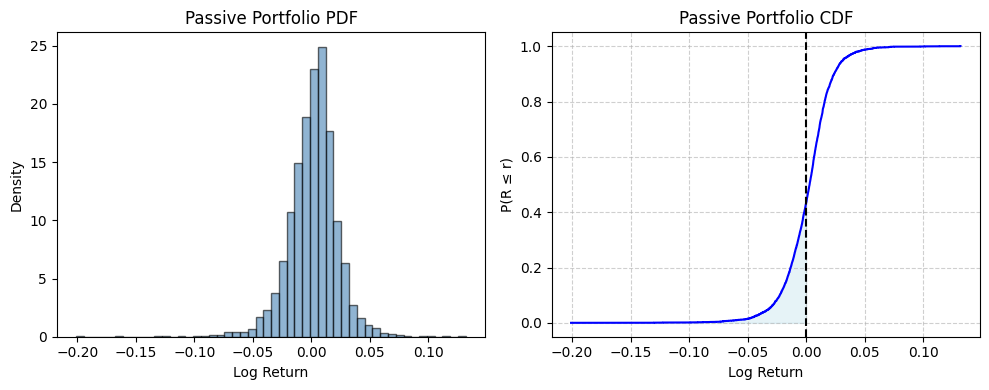

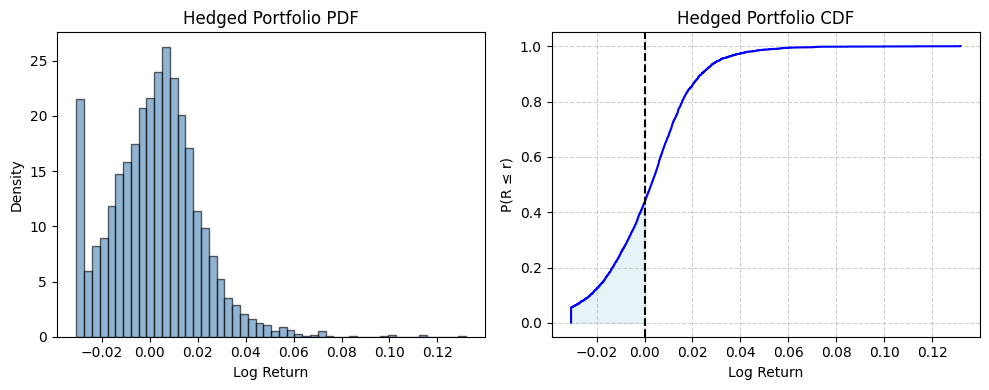

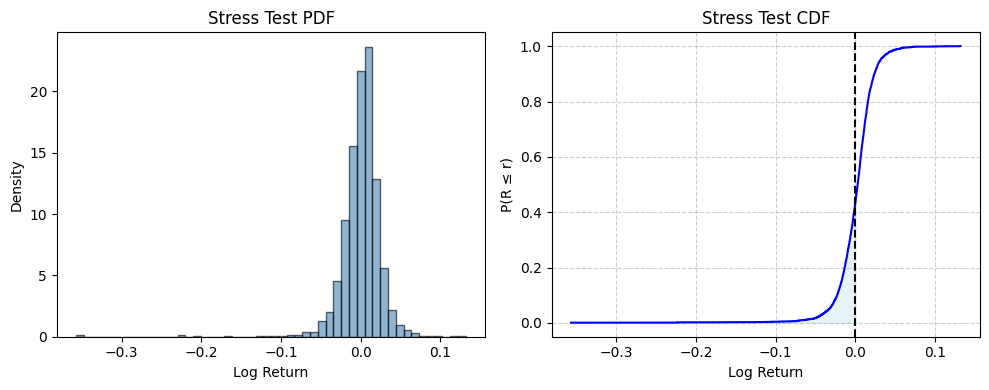

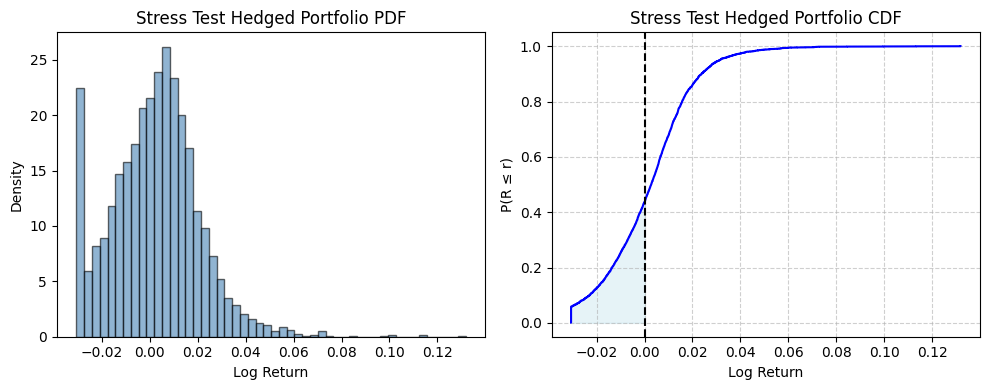

In [10]:
# Visualize all portfolios 
plot_pdf_cdf(log_ret, "Passive Portfolio PDF", "Passive Portfolio CDF")
plot_pdf_cdf(log_ret_with_put, "Hedged Portfolio PDF", "Hedged Portfolio CDF")
plot_pdf_cdf(log_ret_stress, "Stress Test PDF", "Stress Test CDF")
plot_pdf_cdf(log_ret_with_put_stress, "Stress Test Hedged Portfolio PDF", "Stress Test Hedged Portfolio CDF")

Computes, with a fixed threshold **K = -0.032** (roughly the 5% quantile of the unhedged series), the left-tail metrics for the four series. Key result: **Vega collapses to 0** for both put-hedged versions (versus 0.836 for the original and 1.028 in the unhedged stress scenario) — because with the put, the return never falls below that K, so the tail beyond K is empty and the sensitivity there is zero. The semi-deviation `s-` drops from 0.00696 to 0.00608 with the put (and from 0.00761 to 0.00616 under stress), confirming the protection on this metric as well.

In [11]:
#############################################################################################
# Results analysis of V 
#############################################################################################

# Functions calculation 
Omega = 0
Delta_s = 1e-3

# Specific K quantile calculation
K_orig = -0.032 # modify this K to replicate results

# Calculate s^- for each distribution
s_orig = s_minus(log_ret, Omega)
s_put_orig = s_minus(log_ret_with_put, Omega)
s_nohedge = s_minus(log_ret_stress, Omega)
s_put_stress = s_minus(log_ret_with_put_stress, Omega)

# Calculate lambda without common baseline
lambda_orig = lambda_from_s_empirical(s_orig, s_orig)
lambda_put_orig = lambda_from_s_empirical(s_put_orig, s_orig)
lambda_nohedge = lambda_from_s_empirical(s_nohedge, s_orig)
lambda_put_stress = lambda_from_s_empirical(s_put_stress, s_orig)

# Calculate xi_K and Vega with specific K and personalized lambda
xi_orig = xi_K_on_baseline(log_ret, lambda_orig, Omega, K_orig)
V_orig = vega_tail_baseline(log_ret, s_orig, s_orig, Omega, K_orig, Delta_s)

xi_put_orig = xi_K_on_baseline(log_ret_with_put, lambda_put_orig, Omega, K_orig)
V_put_orig = vega_tail_baseline(log_ret_with_put, s_put_orig, s_orig, Omega, K_orig, Delta_s)

xi_nohedge = xi_K_on_baseline(log_ret_stress, lambda_nohedge, Omega, K_orig)
V_nohedge = vega_tail_baseline(log_ret_stress, s_nohedge, s_orig, Omega, K_orig, Delta_s)

xi_put_stress = xi_K_on_baseline(log_ret_with_put_stress, lambda_put_stress, Omega, K_orig)
V_put_stress = vega_tail_baseline(log_ret_with_put_stress, s_put_stress, s_orig, Omega, K_orig, Delta_s)

# Summary DataFrame creation
df_metrics_nobase = pd.DataFrame({
    'Portfolio': [
        'Original unhedged',
        'Original with Put',
        'Stress test unhedged',
        'Stress test with Put'
    ],
    'Semi-deviation s^-': [
        s_orig,
        s_put_orig,
        s_nohedge,
        s_put_stress
    ],
    'Lambda': [
        lambda_orig,
        lambda_put_orig,
        lambda_nohedge,
        lambda_put_stress
    ],
    'Xi(K, s^-)': [
        xi_orig,
        xi_put_orig,
        xi_nohedge,
        xi_put_stress
    ],
    'Vega': [
        V_orig,
        V_put_orig,
        V_nohedge,
        V_put_stress
    ]
})


print("Quantile 0.05 for portfolio without put", K_orig)
print("")
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(df_metrics_nobase.to_string(index=False))

Quantile 0.05 for portfolio without put -0.032

           Portfolio  Semi-deviation s^-   Lambda  Xi(K, s^-)     Vega
   Original unhedged            0.006964 1.000000    0.002466 0.836181
   Original with Put            0.006084 0.873579    0.000000 0.000000
Stress test unhedged            0.007614 1.093252    0.003796 1.028238
Stress test with Put            0.006159 0.884371    0.000000 0.000000


Two plots: on the left, the full CDF and the CDF truncated at K, with Omega and K highlighted; on the right, the effect of rescaling by different lambda values (put-hedged, original, unhedged stress portfolios) on the truncated CDF — visually shows how the framework "compresses" or "expands" the tail depending on the lambda computed for each case.

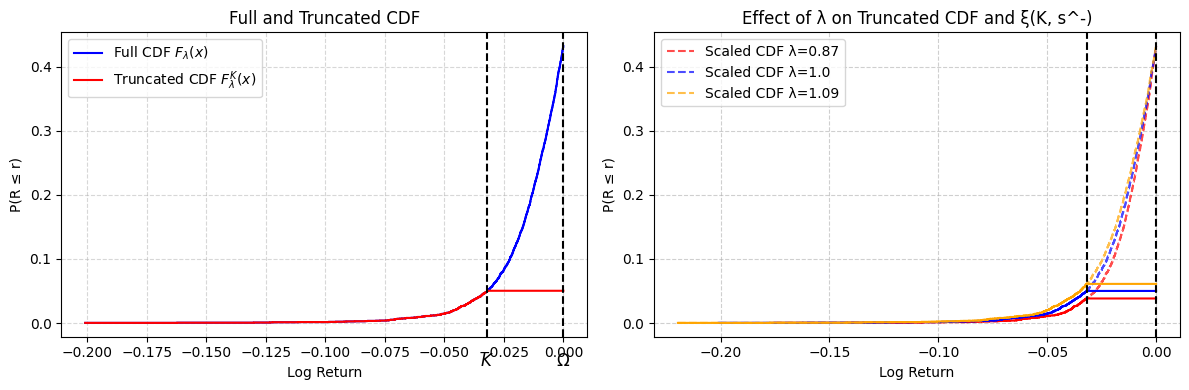

In [12]:
#############################################################################################
# Graphs for the left side
#############################################################################################

x = np.sort(log_ret.to_numpy())
ecdf = ECDF(x)
y = ecdf(x)

Omega = 0.0
K = np.quantile(x, 0.05)

# Mask for left side
mask = x <= Omega

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# First graph: Full and truncated CDF (left side)
mask_K = x <= K
y_cdf = y
y_truncated = np.minimum(y_cdf, y_cdf[np.searchsorted(x, K)])

axs[0].step(x[mask], y_cdf[mask], where='post', color='blue', label=r"Full CDF $F_\lambda(x)$")
axs[0].step(x[mask], y_truncated[mask], where='post', color='red', label=r"Truncated CDF $F^K_\lambda(x)$")
axs[0].axvline(Omega, color='black', linestyle='--')
axs[0].axvline(K, color='black', linestyle='--')

ylim_min, ylim_max = axs[0].get_ylim()
y_pos = ylim_min - 0.05 * (ylim_max - ylim_min)
axs[0].text(Omega, y_pos, r"$\Omega$", ha='center', va='top', fontsize=12)
axs[0].text(K, y_pos, r"$K$", ha='center', va='top', fontsize=12)

axs[0].set_xlabel("Log Return")
axs[0].set_ylabel("P(R ≤ r)")
axs[0].set_title("Full and Truncated CDF")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# Second graph: Scaled and truncated CDF for different λ
lambdas = [lambda_put_orig, lambda_orig, lambda_nohedge]
colors = ['red', 'blue', 'orange']

for lam, c in zip(lambdas, colors):
    scaled_data = Omega + lam * (x - Omega)
    x_scaled = np.sort(scaled_data)
    ecdf_scaled = ECDF(x_scaled)
    y_scaled = ecdf_scaled(x_scaled)

    mask_Omega = x_scaled <= Omega
    F_K = ecdf_scaled(K)
    y_truncated_scaled = np.minimum(y_scaled, F_K)

    axs[1].step(x_scaled[mask_Omega], y_scaled[mask_Omega], where='post', linestyle='--', color=c, alpha=0.7, label=f"Scaled CDF λ={lam.round(2)}")
    axs[1].step(x_scaled[mask_Omega], y_truncated_scaled[mask_Omega], where='post', color=c, )

axs[1].axvline(Omega, color='black', linestyle='--')
axs[1].axvline(K, color='black', linestyle='--')

axs[1].set_xlabel("Log Return")
axs[1].set_ylabel("P(R ≤ r)")
axs[1].set_title("Effect of λ on Truncated CDF and ξ(K, s^-)")
axs[1].legend()
axs[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()



Analyzes how **s-, lambda, xi, and Vega** vary as the threshold Omega ranges between -10% and +10% (500 points), with K fixed at the 5% quantile. The 2x2 grid shows that all four quantities grow almost monotonically as Omega increases (more permissive thresholds imply larger semi-deviations and higher sensitivity), with Omega=0 (red line) as the current reference.

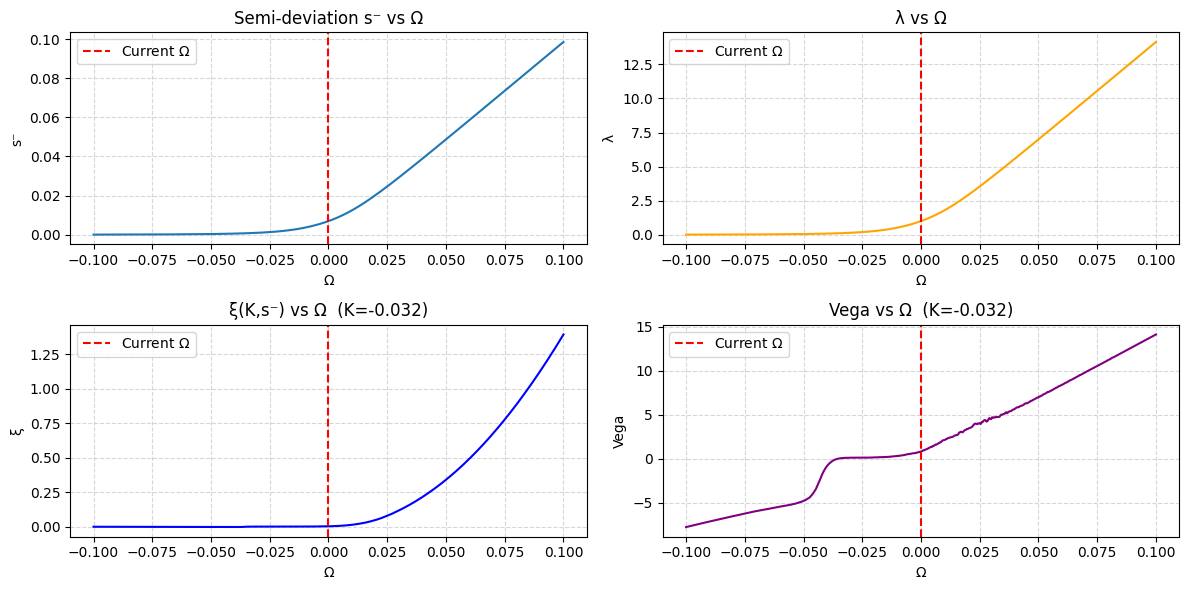

In [13]:
# Graphs for variations of Omega
# Input parameters
Omegas = np.linspace(-0.1, 0.1, 500)    # Omega Range
K = log_ret.quantile(0.05)              # Threshold K
Delta_s = 1e-3
Omega_current = 0.0

# Lists for collecting results
s_list, lambda_list, xi_list, vega_list = [], [], [], []

for Om in Omegas:
    s = s_minus(log_ret, Om)
    lam = lambda_from_s_empirical(s, s_minus(log_ret, Omega_current))
    xi  = xi_K_on_baseline(log_ret, lam, Om, K)
    V   = vega_tail_baseline(log_ret, s, s_minus(log_ret, Omega_current), Om, K, Delta_s)
    
    s_list.append(s)
    lambda_list.append(lam)
    xi_list.append(xi)
    vega_list.append(V)

# Convert to arrays for convenience
s_array      = np.array(s_list)
lambda_array = np.array(lambda_list)
xi_array     = np.array(xi_list)
vega_array   = np.array(vega_list)

# Graphs creation
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# Semi-deviation s^- vs Omega
axs[0,0].plot(Omegas, s_array)
axs[0,0].axvline(Omega_current, color='red', linestyle='--', label=r"Current $\Omega$")
axs[0,0].set_title("Semi-deviation s⁻ vs Ω")
axs[0,0].set_xlabel("Ω")
axs[0,0].set_ylabel("s⁻")
axs[0,0].legend()
axs[0,0].grid(True, linestyle='--', alpha=0.5)

# Lambda vs Omega
axs[0,1].plot(Omegas, lambda_array, color = 'orange')
axs[0,1].axvline(Omega_current, color='red', linestyle='--', label=r"Current $\Omega$")
axs[0,1].set_title("λ vs Ω")
axs[0,1].set_xlabel("Ω")
axs[0,1].set_ylabel("λ")
axs[0,1].legend()
axs[0,1].grid(True, linestyle='--', alpha=0.5)

# Xi vs Omega
axs[1,0].plot(Omegas, xi_array, color='blue')
axs[1,0].axvline(Omega_current, color='red', linestyle='--', label=r"Current $\Omega$")
axs[1,0].set_title(f"ξ(K,s⁻) vs Ω  (K={K:.3f})")
axs[1,0].set_xlabel("Ω")
axs[1,0].set_ylabel("ξ")
axs[1,0].legend()
axs[1,0].grid(True, linestyle='--', alpha=0.5)

# Vega vs Omega
axs[1,1].plot(Omegas, vega_array, color='purple')
axs[1,1].axvline(Omega_current, color='red', linestyle='--', label=r"Current $\Omega$")
axs[1,1].set_title(f"Vega vs Ω  (K={K:.3f})")
axs[1,1].set_xlabel("Ω")
axs[1,1].set_ylabel("Vega")
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Analyzes the sensitivity of **xi** and **Vega** as K varies (from -0.30 to 0, original portfolio), with three reference values highlighted (K=-0.02, -0.03, -0.032). Both curves are monotonically decreasing in absolute value toward more negative K (more extreme thresholds capture less probability mass, hence lower xi and Vega).

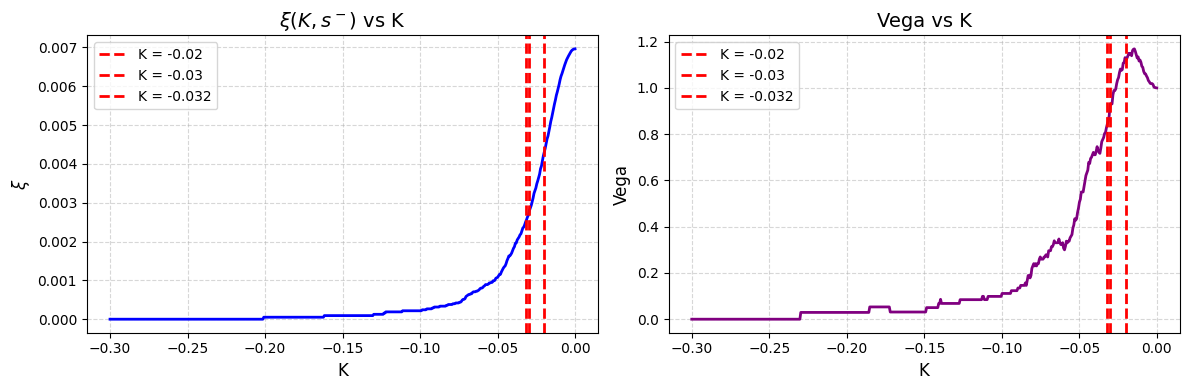

In [14]:
# Graphs for variations of K
# Data parameters
Omega = 0.0
Ks = np.linspace(-0.3, 0.0, 500)  # Range for K
K_current = log_ret.quantile(0.05)  # Fixed current K
Delta_s = 1e-3

# Lists to collect results
s_list, xi_list, vega_list = [], [], []

for Ki in Ks:
    s = s_minus(log_ret, Omega)  # fixed left semi-deviation relative to Omega
    lam = lambda_from_s_empirical(s, s_minus(log_ret, Omega))  # lambda calculated relative to fixed baseline
    xi = xi_K_on_baseline(log_ret, lam, Omega, Ki)
    V = vega_tail_baseline(log_ret, s, s_minus(log_ret, Omega), Omega, Ki, Delta_s)

    s_list.append(s)
    xi_list.append(xi)
    vega_list.append(V)

# Conversion to arrays for plot
xi_array = np.array(xi_list)
vega_array = np.array(vega_list)

# change these to visualize other Ks in the graphs
K_1 = -0.02
K_2 = -0.03
K_3 = log_ret.quantile(0.05)

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: ξ(K,s⁻) vs K
axs[0].plot(Ks, xi_array, color='blue', lw=2)
axs[0].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[0].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[0].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.032')
axs[0].set_title(r'$\xi(K,s^-)$ vs K', fontsize=14)
axs[0].set_xlabel('K', fontsize=12)
axs[0].set_ylabel(r'$\xi$', fontsize=12)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# Graph 2: Vega vs K
axs[1].plot(Ks, vega_array, color='purple', lw=2)
axs[1].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[1].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[1].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.032')
axs[1].set_title('Vega vs K', fontsize=14)
axs[1].set_xlabel('K', fontsize=12)
axs[1].set_ylabel('Vega', fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Same analysis but on the **put-hedged** portfolio. The printed output numerically confirms the Vega collapse observed earlier: **K=-0.02 -> Vega=0.9653**, **K=-0.03 -> Vega=0.9429**, but **K=-0.032 -> Vega=0** — exactly the point where the put's strike (97% of the price, roughly -3% return) eliminates any residual probability of returns beyond that threshold.

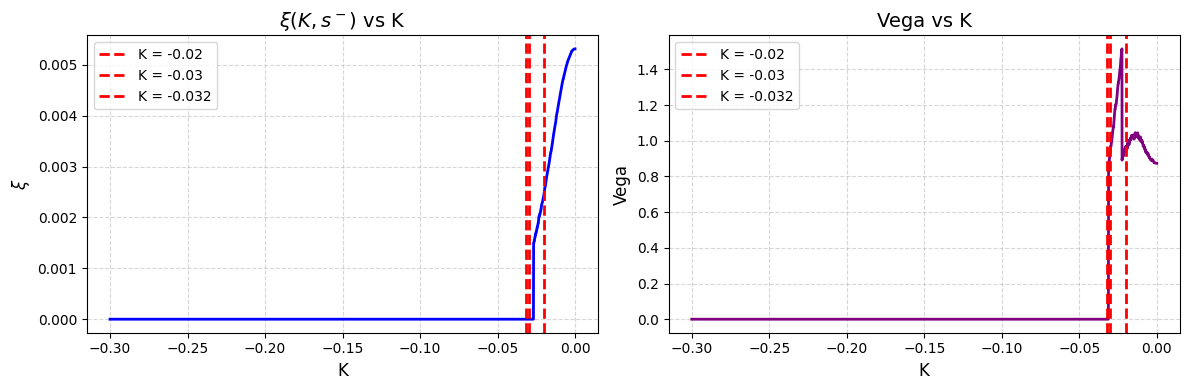

K = -0.020 → Vega = 0.965300
K = -0.030 → Vega = 0.942947
K = -0.032 → Vega = 0.000000


In [15]:
# Analysis of Xi and V relative to variations in K for hedged portfolios

Omega = 0.0
Ks = np.linspace(-0.3, 0.0, 5000)   # Range for K
K_current = -0.02 # Fixed current K
Delta_s = 1e-3

baseline_data = log_ret   # or: log_ret_put

s_list, xi_list, vega_list = [], [], []

for Ki in Ks:
    # fixed left semi-deviation relative to Omega
    s = s_minus(log_ret_with_put, Omega)

    # lambda calculated relative to baseline
    lam = lambda_from_s_empirical(s, s_minus(baseline_data, Omega))

    # calculation of xi and vega on baseline
    xi = xi_K_on_baseline(log_ret_with_put, lam, Omega, Ki)
    V = vega_tail_baseline(log_ret_with_put, s, s_minus(baseline_data, Omega), Omega, Ki, Delta_s)

    # accumulate results
    s_list.append(s)
    xi_list.append(xi)
    vega_list.append(V)


xi_array = np.array(xi_list)
vega_array = np.array(vega_list)


K_1 = -0.02
K_2 = -0.03
K_3 = log_ret.quantile(0.05)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(Ks, xi_array, color='blue', lw=2)
axs[0].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[0].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[0].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.032')
axs[0].set_title(r'$\xi(K,s^-)$ vs K', fontsize=14)
axs[0].set_xlabel('K', fontsize=12)
axs[0].set_ylabel(r'$\xi$', fontsize=12)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(Ks, vega_array, color='purple', lw=2)
axs[1].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[1].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[1].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.032')
axs[1].set_title('Vega vs K', fontsize=14)
axs[1].set_xlabel('K', fontsize=12)
axs[1].set_ylabel('Vega', fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

K_targets = [-0.02, -0.03,-0.032]
for Kt in K_targets:
    idx = np.argmin(np.abs(Ks - Kt))  # index of the closest K value
    print(f"K = {Ks[idx]:.3f} → Vega = {vega_array[idx]:.6f}")

Plots of `s-` itself and of `lambda` as `s-` varies over the interval [0.1x, 3x] of the original value — used to visually verify the expected linear relationship between `s-` and `lambda` (by construction, lambda is proportional to s-).

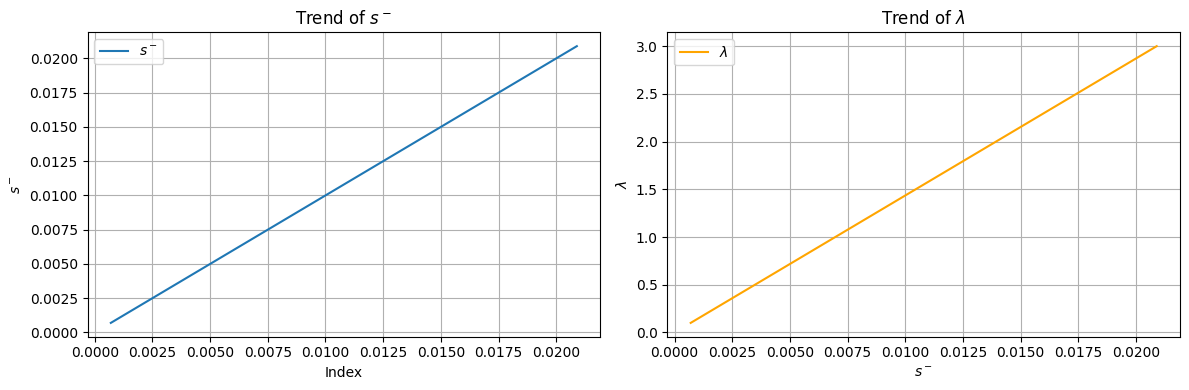

In [16]:
# Graphs for variations of s^-
# Base parameters
Omega = 0.0
Delta_s = 1e-3
K = log_ret.quantile(0.05)

# Baseline left semi-deviation reference
s_left = s_minus(log_ret, Omega)

# Variation of s^-
s_minus_vals = np.linspace(s_left * 0.1, s_left * 3, 500)

lambda_vals = []
xi_vals = []
vega_vals = []

for s_val in s_minus_vals:
    lam = lambda_from_s_empirical(s_val, s_left)  # Calculate lambda relative to baseline s_left
    lambda_vals.append(lam)

    xi = xi_K(log_ret, lam, Omega, K)
    xi_vals.append(xi)

    vega = vega_tail_baseline(log_ret, s_val, s_left, Omega, K, Delta_s)
    vega_vals.append(vega)

# Graph 1: s^- and lambda
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(s_minus_vals, s_minus_vals, label=r'$s^-$')
axs[0].set_title('Trend of $s^-$')
axs[0].set_xlabel('Index')
axs[0].set_ylabel(r'$s^-$')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(s_minus_vals, lambda_vals, color='orange', label=r'$\lambda$')
axs[1].set_title(r'Trend of $\lambda$')
axs[1].set_xlabel(r'$s^-$')
axs[1].set_ylabel(r'$\lambda$')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

Plot of `xi(K,s-)` as `s-` varies: the relationship is increasing and concave, consistent with the definition of xi as the integral of the truncated CDF area — the larger the semi-deviation, the larger the captured tail area, but with diminishing marginal returns.

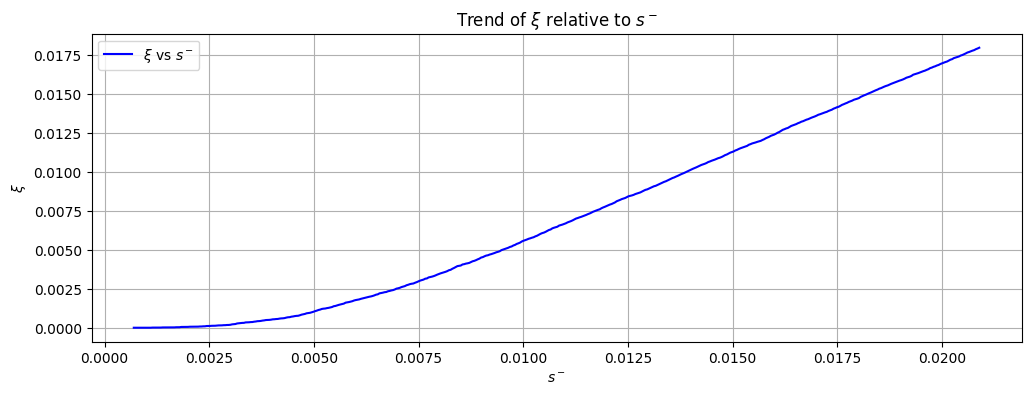

In [17]:
# Graph 2: Xi vs s^-
plt.figure(figsize=(12, 4))
plt.plot(s_minus_vals, xi_vals, label=r'$\xi$ vs $s^-$', color='blue')
plt.xlabel(r'$s^-$')
plt.ylabel(r'$\xi$')
plt.title(r'Trend of $\xi$ relative to $s^-$')
plt.legend()
plt.grid(True)
plt.show()



Compares **Vega vs s-** across the four configurations (original, with put, stress, stress with put) in a 2x2 grid, with a red dashed line at the current value of `s-` for each case. All curves share a similar shape (fast initial growth then flattening), but the put-hedged versions remain systematically lower for the same level of `s-`, confirming the put's dampening effect on tail sensitivity.

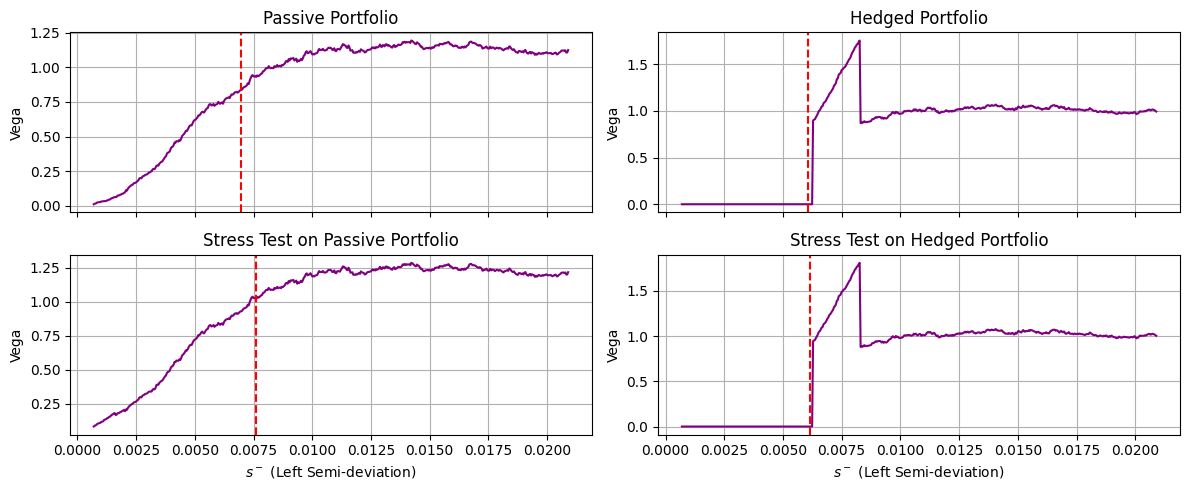

In [18]:
# Vega vs s^- Graphs
Delta_s = 1e-3
s_minus_vals = np.linspace(s_orig * 0.1, s_orig * 3, 500)

vega_vals_orig = [vega_tail_baseline(log_ret, s_val, s_orig, Omega, K_orig, Delta_s) for s_val in s_minus_vals]
vega_vals_put = [vega_tail_baseline(log_ret_with_put, s_val, s_orig, Omega, K_orig, Delta_s) for s_val in s_minus_vals]
vega_vals_stress = [vega_tail_baseline(log_ret_stress, s_val, s_orig, Omega, K_orig, Delta_s) for s_val in s_minus_vals]
vega_vals_stress_put = [vega_tail_baseline(log_ret_with_put_stress, s_val, s_orig, Omega, K_orig, Delta_s) for s_val in s_minus_vals]

fig, axs = plt.subplots(2, 2, figsize=(12, 5), sharex=True)

# Common colors
vega_color = 'purple'
line_color = 'red'

axs[0, 0].plot(s_minus_vals, vega_vals_orig, color=vega_color)
axs[0, 0].axvline(s_orig, color=line_color, linestyle='--')
axs[0, 0].set_title('Passive Portfolio')
axs[0, 0].set_ylabel('Vega')
axs[0, 0].grid(True)

axs[0, 1].plot(s_minus_vals, vega_vals_put, color=vega_color)
axs[0, 1].axvline(s_put_orig, color=line_color, linestyle='--')
axs[0, 1].set_title('Hedged Portfolio')
axs[0, 1].set_ylabel('Vega')
axs[0, 1].grid(True)

axs[1, 0].plot(s_minus_vals, vega_vals_stress, color=vega_color)
axs[1, 0].axvline(s_nohedge, color=line_color, linestyle='--')
axs[1, 0].set_title('Stress Test on Passive Portfolio')
axs[1, 0].set_xlabel(r'$s^-$ (Left Semi-deviation)')
axs[1, 0].set_ylabel('Vega')
axs[1, 0].grid(True)

axs[1, 1].plot(s_minus_vals, vega_vals_stress_put, color=vega_color)
axs[1, 1].axvline(s_put_stress, color=line_color, linestyle='--')
axs[1, 1].set_title('Stress Test on Hedged Portfolio')
axs[1, 1].set_xlabel(r'$s^-$ (Left Semi-deviation)')
axs[1, 1].set_ylabel('Vega')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

Computes the **second derivative of Vega with respect to `s-`** (a measure of second-order "fragility" or convexity) for the same four configurations, over a wider range of `s-` (0.5x-8x). In the plots, the hedged portfolio shows flatter/more stable behavior compared to the original and the stress scenario.

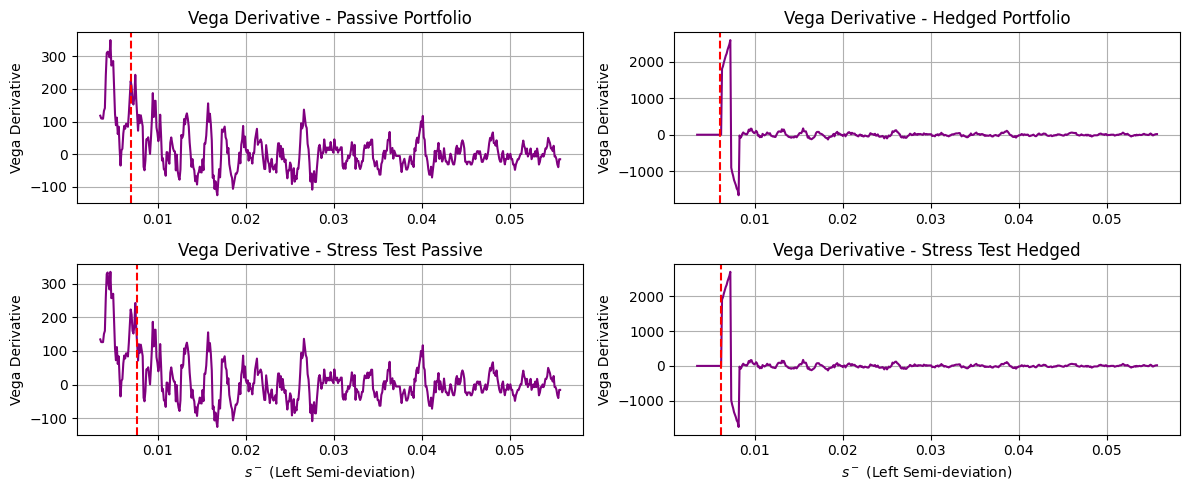

In [19]:
# Second-order fragility graphs
Delta_s = 1e-3

# Specific s^- intervals for each case
s_minus_vals = np.linspace(s_orig * 0.5, s_orig * 8, 500)

# Calculation of Vega derivatives for each case
deriv_vega_vals_orig = [vega_derivative_s_minus(log_ret, s,s_orig, Omega, K_orig, Delta_s) for s in s_minus_vals]
deriv_vega_vals_put = [vega_derivative_s_minus(log_ret_with_put, s,s_orig, Omega, K_orig, Delta_s) for s in s_minus_vals]
deriv_vega_vals_stress = [vega_derivative_s_minus(log_ret_stress, s,s_orig, Omega, K_orig, Delta_s) for s in s_minus_vals]
deriv_vega_vals_stress_put = [vega_derivative_s_minus(log_ret_with_put_stress, s,s_orig, Omega, K_orig, Delta_s) for s in s_minus_vals]

# 2x2 figure creation
fig, axs = plt.subplots(2, 2, figsize=(12, 5), sharex=False)

# Colors
vega_color = 'purple'
line_color = 'red'

# 1. Original unhedged
axs[0, 0].plot(s_minus_vals, deriv_vega_vals_orig, color=vega_color)
axs[0, 0].axvline(s_orig, color=line_color, linestyle='--')
axs[0, 0].set_title('Vega Derivative - Passive Portfolio')
axs[0, 0].set_ylabel('Vega Derivative')
axs[0, 0].grid(True)

# 2. Original with Put
axs[0, 1].plot(s_minus_vals, deriv_vega_vals_put, color=vega_color)
axs[0, 1].axvline(s_put_orig, color=line_color, linestyle='--')
axs[0, 1].set_title('Vega Derivative - Hedged Portfolio')
axs[0, 1].set_ylabel('Vega Derivative')
axs[0, 1].grid(True)

# 3. Stress test unhedged
axs[1, 0].plot(s_minus_vals, deriv_vega_vals_stress, color=vega_color)
axs[1, 0].axvline(s_nohedge, color=line_color, linestyle='--')
axs[1, 0].set_title('Vega Derivative - Stress Test Passive')
axs[1, 0].set_xlabel(r'$s^-$ (Left Semi-deviation)')
axs[1, 0].set_ylabel('Vega Derivative')
axs[1, 0].grid(True)

# 4. Stress test with Put
axs[1, 1].plot(s_minus_vals, deriv_vega_vals_stress_put, color=vega_color)
axs[1, 1].axvline(s_put_stress, color=line_color, linestyle='--')
axs[1, 1].set_title('Vega Derivative - Stress Test Hedged')
axs[1, 1].set_xlabel(r'$s^-$ (Left Semi-deviation)')
axs[1, 1].set_ylabel('Vega Derivative')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

Analyzes the derivative of Vega with respect to **K** (rather than `s-`), over a K range of [-0.06, 0], for the same four configurations, with K=-0.0318 highlighted as a reference. Shows how Vega's sensitivity to changes in the strike/threshold varies depending on whether the portfolio is hedged or not, and under normal or stress conditions.

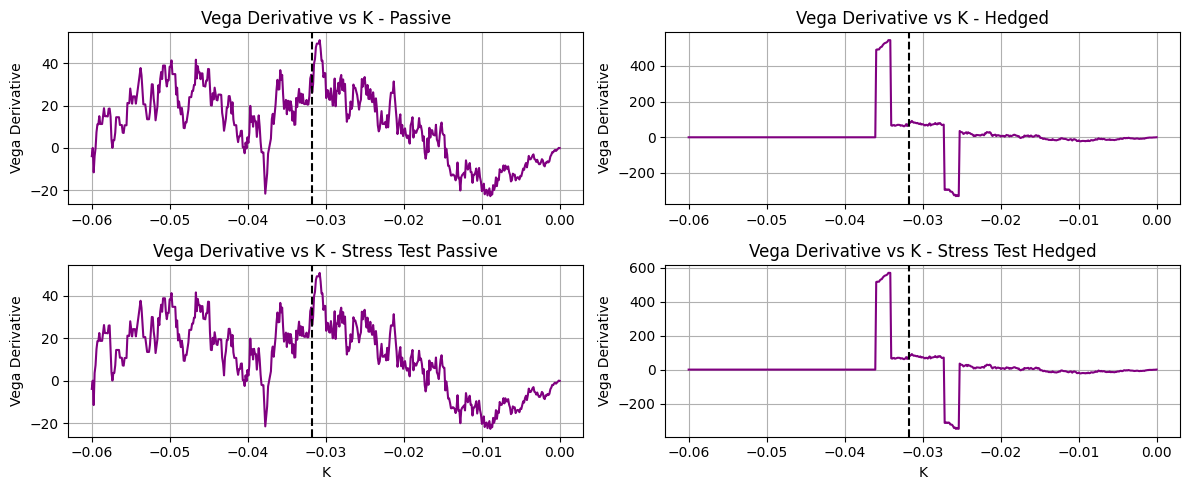

In [20]:
# Fragility drift graphs
# Base parameters
Omega = 0.0
Delta_s = 1e-3
Delta_K = Delta_s
s_orig = s_minus(log_ret, Omega)
K = -0.0318

# Variation intervals
K_vals = np.linspace(-0.06, 0, 500)

# Calculate Vega derivatives relative to K
deriv_vega_K_vals_orig = [vega_derivative_k(log_ret, s_orig, Omega, k, Delta_K) for k in K_vals]
deriv_vega_K_vals_put = [vega_derivative_k(log_ret_with_put, s_orig, Omega, k, Delta_K) for k in K_vals]
deriv_vega_K_vals_stress = [vega_derivative_k(log_ret_stress, s_orig, Omega, k, Delta_K) for k in K_vals]
deriv_vega_K_vals_stress_put = [vega_derivative_k(log_ret_with_put_stress, s_orig, Omega, k, Delta_K) for k in K_vals]

# 2x2 figure creation
fig, axs = plt.subplots(2, 2, figsize=(12, 5), sharex=False)

# Colors
vega_color = 'purple'
line_color = 'red'

# 1. Original unhedged
axs[0, 0].plot(K_vals, deriv_vega_K_vals_orig, label="Vega derivative vs K", color="purple")
axs[0, 0].axvline(K, color='black', linestyle='--',)
axs[0, 0].set_title('Vega Derivative vs K - Passive')
axs[0, 0].set_ylabel('Vega Derivative')
axs[0, 0].grid(True)

# 2. Original with Put
axs[0, 1].plot(K_vals, deriv_vega_K_vals_put, label="Vega derivative vs K", color="purple")
axs[0, 1].axvline(K, color='black', linestyle='--',)
axs[0, 1].set_title('Vega Derivative vs K - Hedged')
axs[0, 1].set_ylabel('Vega Derivative')
axs[0, 1].grid(True)

# 3. Stress test unhedged
axs[1, 0].plot(K_vals, deriv_vega_K_vals_stress, label="Vega derivative vs K", color="purple")
axs[1, 0].axvline(K, color='black', linestyle='--',)
axs[1, 0].set_title('Vega Derivative vs K - Stress Test Passive')
axs[1, 0].set_xlabel(r'K')
axs[1, 0].set_ylabel('Vega Derivative')
axs[1, 0].grid(True)

# 4. Stress test with Put
axs[1, 1].plot(K_vals, deriv_vega_K_vals_stress_put, label="Vega derivative vs K", color="purple")
axs[1, 1].axvline(K, color='black', linestyle='--',)
axs[1, 1].set_title('Vega Derivative vs K - Stress Test Hedged')
axs[1, 1].set_xlabel(r'K')
axs[1, 1].set_ylabel('Vega Derivative')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()



**Section W**: moving from the left-tail analysis (V, downside risk) to the right-tail analysis (W, upside potential), using the survival function P(R>r) in place of the CDF. `plot_pdf_survival` draws the histogram and survival function for the original and put-hedged portfolios, highlighting the area above Omega=0 (probability of a positive return).

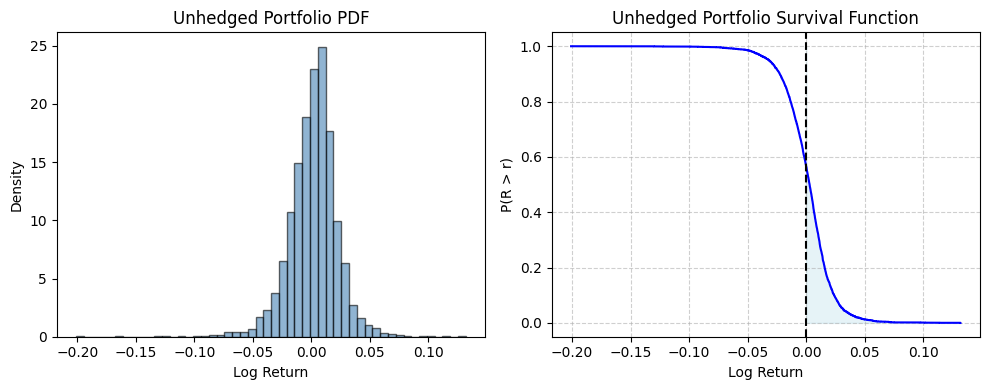

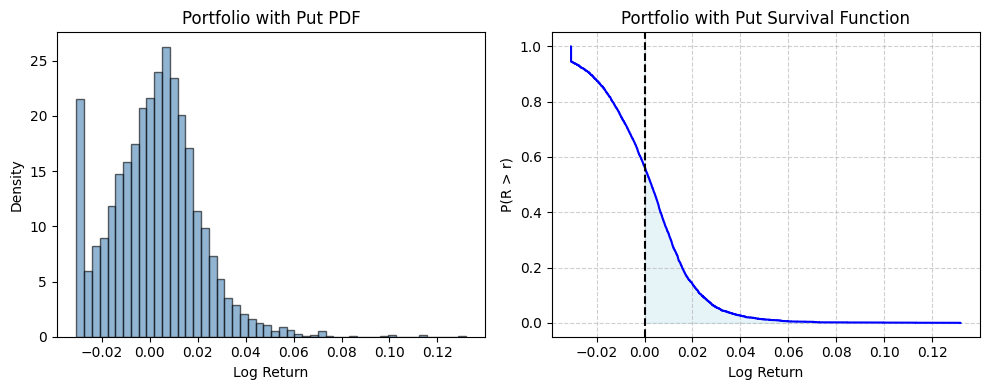

In [21]:
#############################################################################################
# Analysis of W 
#############################################################################################


# Survival function graphs
def plot_pdf_survival(returns, title_pdf, title_survival):
    x = np.sort(returns)
    ecdf = ECDF(returns)
    y_cdf = ecdf(x)
    y_survival = 1 - y_cdf  # survival function

    Omega = 0.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # PDF (normalized histogram)
    axes[0].hist(returns, bins=50, density=True, alpha=0.6,
                 color='steelblue', edgecolor="black")
    axes[0].set_title(title_pdf)
    axes[0].set_xlabel("Log Return")
    axes[0].set_ylabel("Density")

    # Survival function
    axes[1].step(x, y_survival, where="post", color="blue")
    axes[1].set_title(title_survival)
    axes[1].set_xlabel("Log Return")
    axes[1].set_ylabel("P(R > r)")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # Highlight area above Omega (right tail)
    mask = x >= Omega
    if np.any(mask):
        x_fill = np.concatenate(([Omega], x[mask]))
        y_fill = np.concatenate(([1], y_survival[mask]))
        axes[1].fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.3)

    axes[1].axvline(Omega, color='black', linestyle='--')

    plt.tight_layout()
    plt.show()

plot_pdf_survival(log_ret, "Unhedged Portfolio PDF", "Unhedged Portfolio Survival Function")
plot_pdf_survival(log_ret_with_put, "Portfolio with Put PDF", "Portfolio with Put Survival Function")



Compares side by side the survival functions of the original and hedged portfolios: the put entails a small premium that slightly reduces positive returns relative to the original, visible as a minimal leftward shift of the hedged portfolio's survival function.

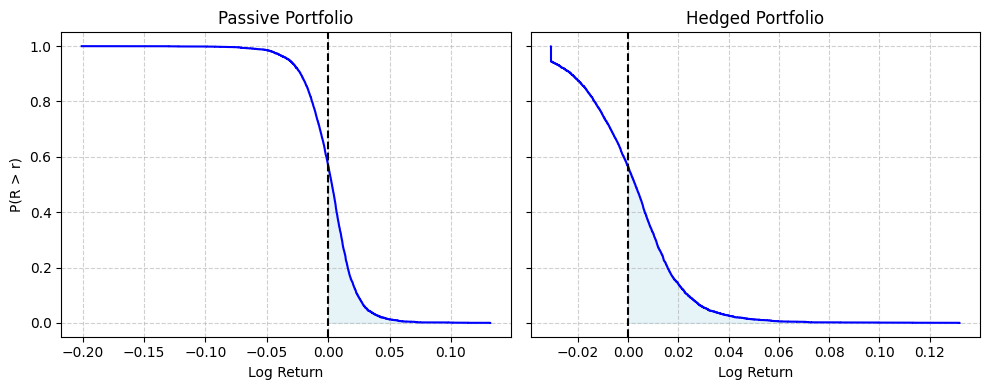

In [22]:
def plot_survival_comparison(returns1, returns2, label1, label2, Omega=0.0):
    x1 = np.sort(returns1)
    x2 = np.sort(returns2)
    ecdf1 = ECDF(returns1)
    ecdf2 = ECDF(returns2)
    y_survival1 = 1 - ecdf1(x1)
    y_survival2 = 1 - ecdf2(x2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Survival function portfolio 1
    axes[0].step(x1, y_survival1, where="post", color="blue", label=label1)
    axes[0].fill_between(x1[x1 >= Omega], 0, (1 - ecdf1(x1[x1 >= Omega])),
                         color='lightblue', alpha=0.3)
    axes[0].axvline(Omega, color='black', linestyle='--')
    axes[0].set_title(label1)
    axes[0].set_xlabel("Log Return")
    axes[0].set_ylabel("P(R > r)")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # Survival function portfolio 2
    axes[1].step(x2, y_survival2, where="post", color="blue", label=label2)
    axes[1].fill_between(x2[x2 >= Omega], 0, (1 - ecdf2(x2[x2 >= Omega])),
                         color='lightblue', alpha=0.3)
    axes[1].axvline(Omega, color='black', linestyle='--')
    axes[1].set_title(label2)
    axes[1].set_xlabel("Log Return")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


# Example usage
plot_survival_comparison(
    log_ret,
    log_ret_with_put,
    "Passive Portfolio",
    "Hedged Portfolio"
)



Computes the right-tail metrics (`s+`, `lambda+`, `xi+`, **W**) with `L=0.03` fixed, comparing original and hedged. Result: **W drops from 0.014347 to 0.013719** with the put — i.e., the hedge also slightly reduces upside sensitivity, the expected cost of paying a premium for protection (there is no free lunch: downside protection is bought by giving up some upside).

In [23]:
#############################################################################################
# Results analysis of W + Graph
#############################################################################################

Omega = 0
Delta_s = 1e-3

# Baseline original returns
baseline_returns = log_ret.copy()

# Single baseline L and H calculation (those of the original portfolio)
L_baseline = 0.03 # modify this to replicate results
H_baseline = log_ret.max()


# Calculate s_plus for original and put portfolio
s_plus_orig = s_plus(log_ret, Omega)
s_plus_put = s_plus(log_ret_with_put, Omega)

# Calculate lambda+ relative to original s_plus baseline
lambda_plus_orig = lambda_from_s_plus_empirical(s_plus_orig, s_plus_orig)
lambda_plus_put = lambda_from_s_plus_empirical(s_plus_put, s_plus_orig)

# Calculate xi+ for the two portfolios with fixed L_baseline and H_baseline
xi_plus_orig = xi_plus_on_baseline(baseline_returns, lambda_plus_orig, Omega, L_baseline, H_baseline)
xi_plus_put = xi_plus_on_baseline(baseline_returns, lambda_plus_put, Omega, L_baseline, H_baseline)

# Calculate sensitivity W with fixed baseline L and H
W_orig = w_vega_right_baseline(log_ret, s_plus_orig, s_plus_orig, Omega, L_baseline, H_baseline, Delta_s)
W_put = w_vega_right_baseline(log_ret_with_put, s_plus_put, s_plus_orig, Omega, L_baseline, H_baseline, Delta_s)

# Summary DataFrame creation without stress test
df_metrics_right_simple = pd.DataFrame({
    'Portfolio': [
        'Original unhedged',
        'Original with Put'
    ],
    'Semi-deviation s^+': [
        s_plus_orig,
        s_plus_put
    ],
    'Lambda^+': [
        lambda_plus_orig,
        lambda_plus_put
    ],
    'Xi^+(L,H)': [
        xi_plus_orig,
        xi_plus_put
    ],
    'W (Vega Sensitivity s^+)': [
        W_orig,
        W_put
    ]
})
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(df_metrics_right_simple.to_string(index=False))

        Portfolio  Semi-deviation s^+  Lambda^+  Xi^+(L,H)  W (Vega Sensitivity s^+)
Original unhedged            0.008457  1.000000   0.000036                  0.014347
Original with Put            0.008345  0.986796   0.000034                  0.013719


Plot of **W vs s+** for the original portfolio, with vertical lines marking the current values of `s+` for both the original and the hedged portfolio — allows a visual comparison of where each portfolio sits on the upside-sensitivity curve.

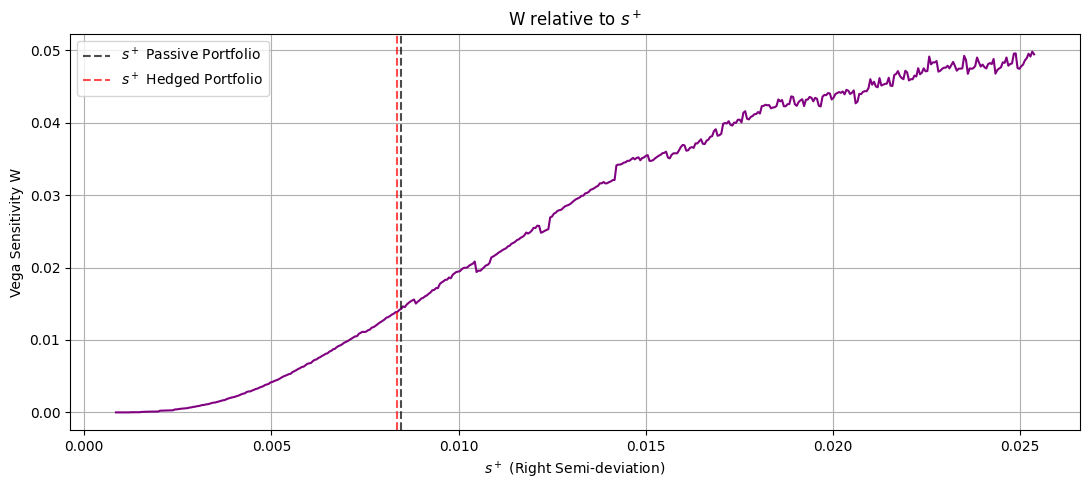

In [24]:
# Interval for s^+
s_plus_vals = np.linspace(s_plus_orig * 0.1, s_plus_orig * 3, 500)

# Calculate W for each s^+ for the original portfolio
W_vals_orig = [w_vega_right_baseline(log_ret, s, s_plus_orig, Omega, L_baseline, H_baseline, Delta_s) for s in s_plus_vals]

plt.figure(figsize=(11, 5))

plt.plot(s_plus_vals, W_vals_orig, color='purple')
plt.axvline(s_plus_orig, color='black', linestyle='--', alpha=0.7, label=r'$s^+$ Passive Portfolio')
plt.axvline(s_plus_put, color='red', linestyle='--', alpha=0.7, label=r'$s^+$ Hedged Portfolio')

plt.title('W relative to $s^+$')
plt.xlabel(r'$s^+$ (Right Semi-deviation)')
plt.ylabel('Vega Sensitivity W')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




**"Barbell" portfolio section**: moving from the S&P 500 index to a basket of 15 assets — 4 large-cap tech stocks (AAPL, MSFT, GOOGL, AMZN), 5 cryptocurrencies (BTC, ETH, LTC, XRP, DOGE), and 6 small-cap/meme stocks (NIO, TRMD, FUBO, AAOI, SPCE, ZM) — over a 2020-2025 horizon, requiring at least 5 years (260 weeks) of history. Defines the `weekly_log_returns` function, which downloads and normalizes (removes the timezone) weekly log-returns for a single ticker.

In [25]:
#############################################################################################
# BARBELL PORTFOLIOS - SINGLE ASSET ANALYSIS
#############################################################################################


# Instruments to include in the portfolio
assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
crypto_candidates = ['BTC-USD', 'ETH-USD', 'LTC-USD', 'XRP-USD', 'DOGE-USD']
smallcap_candidates = ['NIO', 'TRMD', 'FUBO', 'AAOI', 'SPCE', 'ZM']
start = "2020-01-01"
end = "2025-01-01"
min_weeks = 5 * 52  # ≈260 weeks

# Download weekly history and calculate log returns
def weekly_log_returns(ticker, start, end):
    t = yf.Ticker(ticker)
    hist = t.history(start=start, end=end, interval="1wk")[['Close']].rename(columns={'Close': ticker})
    if hist.empty:
        return pd.Series(dtype=float)
    # Normalize index (remove timezones)
    hist.index = pd.to_datetime(hist.index)
    try:
        hist.index = hist.index.tz_convert(None)
    except (TypeError, AttributeError):
        try:
            hist.index = hist.index.tz_localize(None)
        except Exception:
            pass
    lr = np.log(hist[ticker] / hist[ticker].shift(1)).dropna()
    lr.name = ticker
    return lr

Downloads weekly returns for all 15 candidate tickers, discarding any with fewer than 260 weeks of data, and merges them into a single DataFrame (`df_rets`) realigned to Thursday of each week to synchronize the series.

In [26]:
# Download weekly returns
all_candidates = assets + crypto_candidates + smallcap_candidates
returns = {}

for tk in all_candidates:
    try:
        lr = weekly_log_returns(tk, start, end)
        if len(lr) >= min_weeks:
            returns[tk] = lr
        else:
            print(f"Discarded {tk}: {len(lr)} weeks (< {min_weeks})")
    except Exception as e:
        print(f"Error downloading {tk}: {e}")

if not returns:
    raise RuntimeError("No tickers with at least 5 years of weekly data.")

# Build DataFrame 
df_rets = pd.concat(returns.values(), axis=1)
df_rets.columns = list(returns.keys())
df_rets.sort_index(inplace=True)

# Normalize index and resolve timezones / duplicates
df_rets.index = pd.to_datetime(df_rets.index)
try:
    df_rets.index = df_rets.index.tz_convert(None)
except (TypeError, AttributeError):
    try:
        df_rets.index = df_rets.index.tz_localize(None)
    except Exception:
        pass

# Resample to Thursday to uniformize all series
df_rets = df_rets.resample('W-THU').last()

Downloads the risk-free rate from 13-week US Treasury bills (`^IRX`) and converts it to a compounded weekly rate. The first printed value (2020-01-09) is **0.0292% per week**, consistent with short-term rates in early 2020 pre-pandemic (roughly 1.5% annualized).

In [27]:
# --- 3) Risk-free rate (from ^IRX) ---
print("Downloading risk-free rate (^IRX)...")
irx = yf.Ticker("^IRX").history(start=start, end=end, interval="1wk")['Close']
irx.index = pd.to_datetime(irx.index).tz_localize(None)
rf_for_weeks = ((1 + irx / 100) ** (1 / 52) - 1).rename('rf_weekly')
rf_for_weeks = rf_for_weeks.reindex(df_rets.index, method='ffill')
print("Weekly risk-free rate example:")
print(rf_for_weeks.head())

Weekly risk-free rate example:
Date
2020-01-09    0.000292
2020-01-16    0.000287
2020-01-23    0.000292
2020-01-30    0.000294
2020-02-06    0.000294
Freq: W-THU, Name: rf_weekly, dtype: float64


Merges the risky assets and the risk-free rate into the final DataFrame `final_df`, which is saved to `weekly_log_returns_with_rf.csv` — the data foundation for building the barbell portfolios.

*Execution note*: while running this notebook, saving to this file — which sits in a folder synced with Google Drive — occasionally produced a corrupted save (lines merged without a line break), an I/O issue from cloud syncing rather than from the code or analysis logic; resolved by re-running until a clean save was produced.

In [28]:
# Preparation for real portfolio
asset_simple = np.exp(df_rets) - 1

# Align risk-free as additional asset
rf_aligned = rf_for_weeks.reindex(df_rets.index).ffill()
df_rets_with_rf = pd.concat([df_rets, rf_aligned.rename('RF')], axis=1)

# --- 5) Final save ---
final_df = df_rets_with_rf.dropna(how='all')
print("Final DataFrame head (log returns + risk-free):")
print(final_df.head())

final_df.to_csv("weekly_log_returns_with_rf.csv")



Final DataFrame head (log returns + risk-free):
                AAPL      MSFT     GOOGL      AMZN   BTC-USD   ETH-USD  \
Date                                                                     
2020-01-09  0.046779  0.028465  0.025114 -0.019819  0.078205  0.145077   
2020-01-16  0.012364  0.026597  0.035474  0.011996 -0.009317  0.022297   
2020-01-23  0.003532 -0.006266 -0.021653 -0.020694  0.067710  0.038570   
2020-01-30  0.003645  0.084894 -0.003515  0.100738 -0.019163  0.070486   
2020-02-06  0.004752  0.023701  0.043756  0.048161  0.106063  0.220129   

             LTC-USD   XRP-USD  DOGE-USD       NIO      TRMD      FUBO  \
Date                                                                     
2020-01-09  0.230825  0.092665  0.015093  0.148846 -0.025318 -0.050986   
2020-01-16 -0.014301  0.010508 -0.038800  0.318454  0.025318 -0.080043   
2020-01-23  0.051126  0.005559  0.030670 -0.205410 -0.212698  0.000000   
2020-01-30  0.116903  0.112210  0.021402  0.068835 -0.047369 -0

Risk/return table for each individual asset. Large differences emerge across asset classes: **DOGE-USD** has the highest average weekly return (1.87%) but with 20% volatility and a maximum drawdown of -97.6%; **SPCE** has the worst drawdown overall (**-99.94%**); the large-cap stocks (AAPL, MSFT) remain far more stable (3.6-4% volatility, maximum drawdown around -34/-37%).

In [29]:
# RISK/RETURN METRICS FOR EACH ASSET

assets_df = final_df

asset_metrics_df = pd.DataFrame(index=assets_df.columns)

# Mean, volatility, min/max
asset_metrics_df['MeanReturn'] = assets_df.mean()
asset_metrics_df['Volatility'] = assets_df.std()
asset_metrics_df['MinReturns'] = assets_df.min()
asset_metrics_df['MaxReturns'] = assets_df.max()
# Max drawdown
asset_metrics_df['MaxDrawdown'] = assets_df.apply(max_drawdown)
# Historical VaR 5%
asset_metrics_df['VaR_5%'] = assets_df.apply(var_5)
# CVaR (Expected Shortfall) 
alpha = 0.05
asset_metrics_df[f'CVaR_{int(alpha*100)}%'] = assets_df.apply(lambda x: cvar_historical(x, alpha))

# Transpose for readability (rows = metrics, columns = assets)
asset_metrics_df_T = asset_metrics_df.T

print("Risk/return metrics for each asset:")
print('')
print(asset_metrics_df_T.round(4))

Risk/return metrics for each asset:

               AAPL    MSFT   GOOGL    AMZN  BTC-USD  ETH-USD  LTC-USD  \
MeanReturn   0.0048  0.0040  0.0039  0.0032   0.0094   0.0121   0.0031   
Volatility   0.0401  0.0360  0.0410  0.0490   0.0915   0.1192   0.1203   
MinReturns  -0.1734 -0.1146 -0.1440 -0.2199  -0.4145  -0.5665  -0.4735   
MaxReturns   0.1621  0.1034  0.1102  0.1558   0.2792   0.4079   0.3481   
MaxDrawdown -0.3372 -0.3658 -0.4557 -0.6256  -0.8431  -0.8693  -0.9540   
VaR_5%      -0.0608 -0.0543 -0.0711 -0.0823  -0.1178  -0.1723  -0.2021   
CVaR_5%     -0.0896 -0.0830 -0.0993 -0.1226  -0.2016  -0.2778  -0.2851   

             XRP-USD  DOGE-USD     NIO    TRMD    FUBO    AAOI    SPCE  \
MeanReturn    0.0087    0.0187  0.0011  0.0049 -0.0081  0.0042 -0.0141   
Volatility    0.1510    0.2014  0.1140  0.0741  0.1583  0.1338  0.1385   
MinReturns   -0.7078   -0.5417 -0.2657 -0.3197 -0.4703 -0.3245 -0.5760   
MaxReturns    0.8280    1.3398  0.5379  0.5242  0.8511  0.5504  0.3944   


Applies the V/W framework to each individual asset (K=L=0.03 fixed). Quantitatively confirms the expected pattern: the riskier assets (DOGE, XRP, FUBO, SPCE) have much higher Vega and W (Vega>1, W up to 0.23) than the mega-caps (Vega around 1, W between 0.03 and 0.05) and especially than the risk-free asset (`RF`), which has Vega=0.5 and W=0 — no right-tail sensitivity, since the risk-free rate has no "surprising" positive returns.

In [30]:
#############################################################################################
# CALCULATION OF V AND W FOR EACH ASSET
#############################################################################################

asset_tail_metrics_df = pd.DataFrame(index=final_df.columns, 
                                     columns=['s_minus', 'xi', 'Vega', 's_plus', 'xi_plus', 'W'])

Omega = 0
quantile = 0.05
Delta_s = 1e-2

for asset in final_df.columns:
    data = final_df[asset].dropna()
    if data.empty:
        continue
    
    # Left tail
    K = -0.03 #np.quantile(data, quantile) # alternatively
    s_minus_val = s_minus(data, Omega)
    lambda_minus = lambda_from_s_empirical(s_minus_val, s_minus_val)
    xi_minus_val = xi_K_on_baseline(data, lambda_minus, Omega, K)
    V_val = vega_tail_baseline(data, s_minus_val, s_minus_val, Omega, K, Delta_s)
    
    # Right tail
    L = 0.03 #np.quantile(data, 1 - quantile) = alternatively
    s_plus_val = s_plus(data, Omega)
    lambda_plus = lambda_from_s_plus_empirical(s_plus_val, s_plus_val)
    xi_plus_val = xi_plus_on_baseline(data, lambda_plus, Omega, L, data.max())
    W_val = w_vega_right_baseline(data, s_plus_val, s_plus_val, Omega, L, data.max(), Delta_s=1e-2)
    
    asset_tail_metrics_df.loc[asset] = [s_minus_val, xi_minus_val, V_val, s_plus_val, xi_plus_val, W_val]

asset_tail_metrics_df = asset_tail_metrics_df


print('')
print("Tail metrics for each asset:")
print('')
print(asset_tail_metrics_df.round(4))

#############################################################################################
# BARBELL PORTFOLIO CREATION AND V/W CALCULATION FOR EACH PORTFOLIO
#############################################################################################


Tail metrics for each asset:

           s_minus        xi      Vega    s_plus   xi_plus         W
AAPL      0.012834  0.009737  1.016719  0.017611  0.000274  0.039146
MSFT      0.011886  0.008788  0.976045  0.015841  0.000193  0.029161
GOOGL      0.01352  0.009765  1.031512  0.017374   0.00027  0.032579
AMZN      0.016389  0.012263  1.066291  0.019594  0.000417    0.0469
BTC-USD   0.028904   0.02655  1.079806  0.038279  0.002125   0.10573
ETH-USD    0.03709  0.035326  1.024617  0.049186  0.003571  0.131049
LTC-USD   0.043314  0.041504   1.01677  0.046382  0.003131  0.131141
XRP-USD   0.043062  0.040937   1.03125  0.051811  0.006494  0.226169
DOGE-USD  0.046976  0.045284  1.073105   0.06569  0.014112   0.22783
NIO       0.042682  0.041006  1.032024  0.043823  0.003435   0.14667
TRMD      0.023444  0.020787  1.105705  0.028354  0.001335  0.079845
FUBO      0.060492   0.05917  1.023357  0.052426  0.006052  0.195422
AAOI      0.045613   0.04375  1.042942  0.049794  0.004982  0.175009
SPC

**85% RF portfolio block** (4 cells): (1) builds 6 portfolio variants with 85% of capital in the risk-free asset and 15% in risky assets — MinVar (minimum variance via cvxpy), HighRisk (concentrated in the 5 most volatile assets), EqualWeight, and three SR_1/2/3 portfolios with increasing target returns (0.5%/0.7%/1.0% weekly) — verifying that weights always sum to 1; (2) computes the historical return series for each variant and saves them to `portfolio_returns_85RF.csv`; (3) computes risk/return metrics — the best Sharpe is **SR_2 (0.1347)**, the worst is **HighRisk (0.0152)**, consistent with the idea that concentrating risk in a few highly volatile assets does not pay off on a risk-adjusted basis; (4) computes the V/W tail metrics for each variant, confirming that HighRisk has the highest Vega (0.724) and MinVar the lowest (0.550), mirroring their riskiness.

In [31]:
#############################################################################################
# PORTFOLIO 85% RF
#############################################################################################

rf_weight = 0.85                # 85% capital in risk-free
risk_asset_weight = 1 - rf_weight
min_weight_per_asset = 0.01     # CONSTRAINT: at least 1% for each risky asset

# Identify columns for risky assets (excluding 'RF')
risky_assets_cols = [col for col in final_df.columns if col != 'RF']

# Redefine data with only risky assets
assets_returns = final_df[risky_assets_cols]
mu = assets_returns.mean()
Sigma = assets_returns.cov()
n_assets = len(assets_returns.columns) # CORRECT: n_assets = 15

# Keep RF series separate
rf_series = final_df['RF']

# PORTFOLIO CONSTRUCTION
weights_minvar = solve_portfolio(constraints_minvar, objective_minvar)
weights_minvar['RF'] = rf_weight

# HighRisk
vols = assets_returns.std().sort_values(ascending=False)
top_risky = vols.index[:5]
weights_highrisk = pd.Series(0.0, index=assets_returns.columns)
weights_highrisk[top_risky] = risk_asset_weight / len(top_risky)
weights_highrisk['RF'] = rf_weight

# Equal Weight
weights_equal = pd.Series(risk_asset_weight / n_assets, index=assets_returns.columns)
weights_equal['RF'] = rf_weight

# Target risk/return portfolios (SR) 
target_returns = [0.005, 0.007, 0.010]  # low, medium, high
weights_sr_list = []

for i, tr in enumerate(target_returns, 1):
    def constraints_sr(w):
        return [cp.sum(w) == 1, 
                w >= min_weight_per_asset, 
                cp.sum(cp.multiply(mu.values, w)) >= tr]
    w_sr = solve_portfolio(constraints_sr, objective_minvar)
    w_sr['RF'] = rf_weight
    weights_sr_list.append((f"SR_{i}", w_sr))

# Final portfolios DataFrame
portfolios_dict = {
    'MinVar': weights_minvar,
    'HighRisk': weights_highrisk,
    'EqualWeight': weights_equal
}
for name, w_sr in weights_sr_list:
    portfolios_dict[name] = w_sr

barbell_85_rf = pd.DataFrame(portfolios_dict)
barbell_85_rf = barbell_85_rf[sorted(barbell_85_rf.columns)]
print("Barbell portfolios 85% RF:")
print(barbell_85_rf.round(4))

# Weights check
sum_weights = barbell_85_rf.sum()
print("Sum of weights for each portfolio:")
print(sum_weights.round(8))

Barbell portfolios 85% RF:
          EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
AAPL             0.01      0.00  0.0340  0.0586  0.0649  0.0271
MSFT             0.01      0.00  0.0546  0.0318  0.0015  0.0015
GOOGL            0.01      0.00  0.0200  0.0075  0.0015  0.0015
AMZN             0.01      0.00  0.0015  0.0015  0.0015  0.0015
BTC-USD          0.01      0.00  0.0015  0.0036  0.0160  0.0061
ETH-USD          0.01      0.00  0.0015  0.0015  0.0046  0.0369
LTC-USD          0.01      0.00  0.0015  0.0015  0.0015  0.0015
XRP-USD          0.01      0.03  0.0015  0.0015  0.0015  0.0015
DOGE-USD         0.01      0.03  0.0015  0.0068  0.0204  0.0390
NIO              0.01      0.00  0.0015  0.0015  0.0015  0.0015
TRMD             0.01      0.00  0.0249  0.0282  0.0292  0.0259
FUBO             0.01      0.03  0.0015  0.0015  0.0015  0.0015
AAOI             0.01      0.03  0.0015  0.0015  0.0015  0.0015
SPCE             0.01      0.03  0.0015  0.0015  0.0015  0.0015
ZM           

In [32]:
# CALCULATION OF HISTORICAL RETURNS SERIES
port_returns_df = pd.DataFrame(index=final_df.index)

for col in barbell_85_rf.columns:
    weights = barbell_85_rf[col]
    port_returns_df[col] = (assets_returns * weights[assets_returns.columns]).sum(axis=1) + weights['RF'] * rf_series

print("\nHistorical returns series of portfolios:")
print(port_returns_df.head())

# Save portfolio returns to CSV
port_returns_df.to_csv('portfolio_returns_85RF.csv')




Historical returns series of portfolios:
            EqualWeight  HighRisk    MinVar      SR_1      SR_2      SR_3
Date                                                                     
2020-01-09     0.010729  0.011423  0.004723  0.005077  0.005951  0.008464
2020-01-16     0.005948  0.003059  0.004162  0.003276  0.001784  0.001324
2020-01-23    -0.003343  0.000763 -0.005892 -0.005774 -0.004271 -0.002557
2020-01-30     0.007054  0.003936  0.004722  0.002841  0.000537  0.003418
2020-02-06     0.009156  0.011655  0.004852  0.005284  0.009019  0.018382


In [33]:
# RISK/RETURN METRICS

metrics_df = pd.DataFrame(index=barbell_85_rf.columns)
metrics_df['MeanReturn'] = port_returns_df.mean()
metrics_df['Volatility'] = port_returns_df.std()
metrics_df['Sharpe'] = (port_returns_df.mean() - rf_series.mean()) / port_returns_df.std()
metrics_df['MinReturns'] = port_returns_df.min()
metrics_df['MaxReturns'] = port_returns_df.max()
metrics_df['MaxDrawdown'] = port_returns_df.apply(max_drawdown)
metrics_df['VaR_5%'] = port_returns_df.apply(var_5)
alpha = 0.05
metrics_df[f'CVaR_{int(alpha*100)}%'] = port_returns_df.apply(lambda x: cvar_historical(x, alpha))
metrics_df_T = metrics_df.T

print("\n Risk/return metrics (transposed):")
print(metrics_df_T.round(4))


 Risk/return metrics (transposed):
             EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
MeanReturn        0.0010    0.0007  0.0010  0.0011  0.0014  0.0019
Volatility        0.0087    0.0142  0.0049  0.0052  0.0073  0.0123
Sharpe            0.0566    0.0152  0.1157  0.1308  0.1347  0.1164
MinReturns       -0.0330   -0.0414 -0.0184 -0.0205 -0.0264 -0.0418
MaxReturns        0.0257    0.0556  0.0135  0.0135  0.0267  0.0555
MaxDrawdown      -0.1358   -0.2358 -0.0373 -0.0385 -0.0653 -0.1346
VaR_5%           -0.0140   -0.0207 -0.0069 -0.0076 -0.0100 -0.0157
CVaR_5%          -0.0209   -0.0287 -0.0113 -0.0120 -0.0161 -0.0252


In [34]:
# TAIL METRICS
tail_metrics_df = pd.DataFrame(index=barbell_85_rf.columns, 
                               columns=['s_minus', 'xi', 'Vega', 's_plus', 'xi_plus', 'W'])

Omega = 0
K, L, Delta_s = -0.01, 0.01, 1e-3 # CHANGE THESE TO REPLICATE RESULTS


Delta_s = 1e-2
for port in barbell_85_rf.columns:
    data = port_returns_df[port]
    s_minus_val = s_minus(data, Omega)
    lambda_minus = lambda_from_s_empirical(s_minus_val, s_minus_val)
    xi_minus_val = xi_K_on_baseline(data, lambda_minus, Omega, K)
    V_val = vega_tail_baseline(data, s_minus_val, s_minus_val, Omega, K, Delta_s)
    s_plus_val = s_plus(data, Omega)
    lambda_plus = lambda_from_s_plus_empirical(s_plus_val, s_plus_val)
    xi_plus_val = xi_plus_on_baseline(data, lambda_plus, Omega, L, data.max())
    W_val = w_vega_right_baseline(data, s_plus_val, s_plus_val, Omega, L, data.max(), Delta_s)
    tail_metrics_df.loc[port] = [s_minus_val, xi_minus_val, V_val, s_plus_val, xi_plus_val, W_val]

print("\n Tail metrics for portfolios (85% RF):")
print(tail_metrics_df.round(4))




 Tail metrics for portfolios (85% RF):
              s_minus        xi      Vega    s_plus   xi_plus         W
EqualWeight  0.002842  0.001565  0.613535  0.003804  0.000007  0.004006
HighRisk      0.00496  0.003693   0.72402  0.005644   0.00004  0.010958
MinVar       0.001382  0.000337  0.550345  0.002416       0.0  0.000717
SR_1         0.001404  0.000442  0.545738  0.002552  0.000001  0.000647
SR_2          0.00193  0.000844  0.565071  0.003379  0.000006  0.003998
SR_3         0.003272  0.002057  0.619299  0.005171  0.000035    0.0104


**90% RF portfolio block**: same 4-step sequence with 90% in the risk-free asset (10% in risky assets). As expected, volatility and drawdown decrease proportionally relative to the 85% block (e.g., EqualWeight volatility drops from 0.87% to 0.58%), while Sharpe ratios remain nearly identical (SR_2 still the best, 0.1346), since both the excess return and the risk scale together with the risky capital share.

In [35]:
#############################################################################################
# PORTFOLIO 90% RF
#############################################################################################

rf_weight = 0.90                # 90% capital in risk-free
risk_asset_weight = 1 - rf_weight
min_weight_per_asset = 0.01     # at least 1% for each risky asset

# Identify columns for risky assets (excluding 'RF')
risky_assets_cols = [col for col in final_df.columns if col != 'RF']

# Redefine data with only risky assets
assets_returns = final_df[risky_assets_cols]
mu = assets_returns.mean()
Sigma = assets_returns.cov()
n_assets = len(assets_returns.columns)

# Keep RF series separate
rf_series = final_df['RF']

# PORTFOLIO CONSTRUCTION
weights_minvar = solve_portfolio(constraints_minvar, objective_minvar)
weights_minvar['RF'] = rf_weight

# HighRisk
vols = assets_returns.std().sort_values(ascending=False)
top_risky = vols.index[:5]
weights_highrisk = pd.Series(0.0, index=assets_returns.columns)
weights_highrisk[top_risky] = risk_asset_weight / len(top_risky)
weights_highrisk['RF'] = rf_weight

# Equal Weight 
weights_equal = pd.Series(risk_asset_weight / n_assets, index=assets_returns.columns)
weights_equal['RF'] = rf_weight

# Target risk/return portfolios (SR) 
target_returns = [0.005, 0.007, 0.010]
weights_sr_list = []

for i, tr in enumerate(target_returns, 1):
    def constraints_sr(w):
        return [cp.sum(w) == 1, 
                w >= min_weight_per_asset, 
                cp.sum(cp.multiply(mu.values, w)) >= tr]
    w_sr = solve_portfolio(constraints_sr, objective_minvar)
    w_sr['RF'] = rf_weight
    weights_sr_list.append((f"SR_{i}", w_sr))

# Final portfolios DataFrame 
portfolios_dict = {
    'MinVar': weights_minvar,
    'HighRisk': weights_highrisk,
    'EqualWeight': weights_equal
}
for name, w_sr in weights_sr_list:
    portfolios_dict[name] = w_sr

barbell_90_rf = pd.DataFrame(portfolios_dict)
barbell_90_rf = barbell_90_rf[sorted(barbell_90_rf.columns)]
print("Barbell portfolios 90% RF:")
print(barbell_90_rf.round(4))

# Weights sum check
sum_weights = barbell_90_rf.sum()
print('')
print("Sum of weights for each portfolio:")
print(sum_weights.round(8))

Barbell portfolios 90% RF:
          EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
AAPL           0.0067      0.00  0.0227  0.0390  0.0433  0.0181
MSFT           0.0067      0.00  0.0364  0.0212  0.0010  0.0010
GOOGL          0.0067      0.00  0.0133  0.0050  0.0010  0.0010
AMZN           0.0067      0.00  0.0010  0.0010  0.0010  0.0010
BTC-USD        0.0067      0.00  0.0010  0.0024  0.0106  0.0041
ETH-USD        0.0067      0.00  0.0010  0.0010  0.0031  0.0246
LTC-USD        0.0067      0.00  0.0010  0.0010  0.0010  0.0010
XRP-USD        0.0067      0.02  0.0010  0.0010  0.0010  0.0010
DOGE-USD       0.0067      0.02  0.0010  0.0045  0.0136  0.0260
NIO            0.0067      0.00  0.0010  0.0010  0.0010  0.0010
TRMD           0.0067      0.00  0.0166  0.0188  0.0194  0.0173
FUBO           0.0067      0.02  0.0010  0.0010  0.0010  0.0010
AAOI           0.0067      0.02  0.0010  0.0010  0.0010  0.0010
SPCE           0.0067      0.02  0.0010  0.0010  0.0010  0.0010
ZM           

In [36]:
# CALCULATION OF HISTORICAL RETURNS SERIES

port_returns_df = pd.DataFrame(index=final_df.index)

for col in barbell_90_rf.columns:
    weights = barbell_90_rf[col]
    port_returns_df[col] = (assets_returns * weights[assets_returns.columns]).sum(axis=1) + weights['RF'] * rf_series

print("\nHistorical returns series of portfolios:")
print(port_returns_df.head())

# Save portfolio returns to CSV
port_returns_df.to_csv('portfolio_returns_90RF.csv')


Historical returns series of portfolios:
            EqualWeight  HighRisk    MinVar      SR_1      SR_2      SR_3
Date                                                                     
2020-01-09     0.007250  0.007712  0.003246  0.003482  0.004065  0.005740
2020-01-16     0.004061  0.002135  0.002870  0.002279  0.001285  0.000978
2020-01-23    -0.002131  0.000606 -0.003830 -0.003752 -0.002750 -0.001607
2020-01-30     0.004800  0.002722  0.003246  0.001992  0.000456  0.002377
2020-02-06     0.006202  0.007868  0.003333  0.003620  0.006110  0.012353


In [37]:
# RISK/RETURN METRICS
metrics_df = pd.DataFrame(index=barbell_90_rf.columns)
metrics_df['MeanReturn'] = port_returns_df.mean()
metrics_df['Volatility'] = port_returns_df.std()
metrics_df['Sharpe'] = (port_returns_df.mean() - rf_series.mean()) / port_returns_df.std()
metrics_df['MinReturns'] = port_returns_df.min()
metrics_df['MaxReturns'] = port_returns_df.max()
metrics_df['MaxDrawdown'] = port_returns_df.apply(max_drawdown)
metrics_df['VaR_5%'] = port_returns_df.apply(var_5)
alpha = 0.05
metrics_df[f'CVaR_{int(alpha*100)}%'] = port_returns_df.apply(lambda x: cvar_historical(x, alpha))
metrics_df_T = metrics_df.T

print("\n Risk/return metrics (transposed):")
print(metrics_df_T.round(4))


 Risk/return metrics (transposed):
             EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
MeanReturn        0.0008    0.0006  0.0008  0.0009  0.0011  0.0014
Volatility        0.0058    0.0095  0.0033  0.0035  0.0049  0.0082
Sharpe            0.0565    0.0152  0.1152  0.1305  0.1346  0.1164
MinReturns       -0.0220   -0.0276 -0.0123 -0.0137 -0.0175 -0.0279
MaxReturns        0.0174    0.0371  0.0091  0.0090  0.0178  0.0370
MaxDrawdown      -0.0914   -0.1570 -0.0248 -0.0256 -0.0428 -0.0896
VaR_5%           -0.0091   -0.0138 -0.0045 -0.0050 -0.0066 -0.0103
CVaR_5%          -0.0138   -0.0190 -0.0074 -0.0079 -0.0106 -0.0167


In [38]:
# TAIL METRICS
tail_metrics_df = pd.DataFrame(index=barbell_90_rf.columns, 
                               columns=['s_minus', 'xi', 'Vega', 's_plus', 'xi_plus', 'W'])

Omega = 0
K, L, Delta_s = -0.01, 0.01, 1e-3 # CHANGE THESE TO REPLICATE RESULTS

for port in barbell_90_rf.columns:
    data = port_returns_df[port]
    s_minus_val = s_minus(data, Omega)
    lambda_minus = lambda_from_s_empirical(s_minus_val, s_minus_val)
    xi_minus_val = xi_K_on_baseline(data, lambda_minus, Omega, K)
    V_val = vega_tail_baseline(data, s_minus_val, s_minus_val, Omega, K, Delta_s)
    s_plus_val = s_plus(data, Omega)
    lambda_plus = lambda_from_s_plus_empirical(s_plus_val, s_plus_val)
    xi_plus_val = xi_plus_on_baseline(data, lambda_plus, Omega, L, data.max())
    W_val = w_vega_right_baseline(data, s_plus_val, s_plus_val, Omega, L, data.max(), Delta_s)
    tail_metrics_df.loc[port] = [s_minus_val, xi_minus_val, V_val, s_plus_val, xi_plus_val, W_val]

print("\n Tail metrics for portfolios (90% RF):")
print(tail_metrics_df.round(4))




 Tail metrics for portfolios (90% RF):
              s_minus        xi      Vega    s_plus   xi_plus         W
EqualWeight  0.001838  0.000655   0.81826  0.002635  0.000002  0.002313
HighRisk      0.00324  0.001712  1.142891  0.003852  0.000014  0.008257
MinVar       0.000872  0.000131  0.379156  0.001718       0.0       0.0
SR_1         0.000889  0.000146  0.458057  0.001811       0.0       0.0
SR_2         0.001234  0.000233  0.608731  0.002356  0.000001  0.001606
SR_3         0.002117  0.000914  0.865919  0.003539  0.000012  0.008247


**95% RF portfolio block**: same sequence with only 5% in risky assets. The pattern is further confirmed: even lower volatilities (EqualWeight at 0.29%), Sharpe ratios essentially unchanged (SR_2 at 0.1335), and the V/W tail metrics scale down almost proportionally with the risky weight — demonstrating that the "barbell" structure preserves the relative risk-return profile across variants regardless of how much capital is allocated to the risk-free asset.

In [39]:
#############################################################################################
# PORTFOLIO 95% RF
#############################################################################################

rf_weight = 0.95                # 95% capital in risk-free
risk_asset_weight = 1 - rf_weight
min_weight_per_asset = 0.01     # at least 1% for each risky asset

# Identify columns for risky assets (excluding 'RF')
risky_assets_cols = [col for col in final_df.columns if col != 'RF']

# Redefine data with only risky assets
assets_returns = final_df[risky_assets_cols]
mu = assets_returns.mean()
Sigma = assets_returns.cov()
n_assets = len(assets_returns.columns)

# Keep RF series separate
rf_series = final_df['RF']

# PORTFOLIO CONSTRUCTION
weights_minvar = solve_portfolio(constraints_minvar, objective_minvar)
weights_minvar['RF'] = rf_weight

# HighRisk
vols = assets_returns.std().sort_values(ascending=False)
top_risky = vols.index[:5]
weights_highrisk = pd.Series(0.0, index=assets_returns.columns)
weights_highrisk[top_risky] = risk_asset_weight / len(top_risky)
weights_highrisk['RF'] = rf_weight

# Equal Weight 
weights_equal = pd.Series(risk_asset_weight / n_assets, index=assets_returns.columns)
weights_equal['RF'] = rf_weight

# Target risk/return portfolios (SR) 
target_returns = [0.005, 0.007, 0.010]
weights_sr_list = []

for i, tr in enumerate(target_returns, 1):
    def constraints_sr(w):
        return [cp.sum(w) == 1, w >= min_weight_per_asset, cp.sum(cp.multiply(mu.values, w)) >= tr]
    w_sr = solve_portfolio(constraints_sr, objective_minvar)
    w_sr['RF'] = rf_weight
    weights_sr_list.append((f"SR_{i}", w_sr))

portfolios_dict = {
    'MinVar': weights_minvar,
    'HighRisk': weights_highrisk,
    'EqualWeight': weights_equal
}
for name, w_sr in weights_sr_list:
    portfolios_dict[name] = w_sr

barbell_95_rf = pd.DataFrame(portfolios_dict)
barbell_95_rf = barbell_95_rf[sorted(barbell_95_rf.columns)]
print("Barbell portfolios 95% RF:")
print(barbell_95_rf.round(4))

# Weights sum check
sum_weights = barbell_95_rf.sum()
print('')
print("Sum of weights for each portfolio:")
print(sum_weights.round(8))

Barbell portfolios 95% RF:
          EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
AAPL           0.0033      0.00  0.0113  0.0195  0.0216  0.0090
MSFT           0.0033      0.00  0.0182  0.0106  0.0005  0.0005
GOOGL          0.0033      0.00  0.0067  0.0025  0.0005  0.0005
AMZN           0.0033      0.00  0.0005  0.0005  0.0005  0.0005
BTC-USD        0.0033      0.00  0.0005  0.0012  0.0053  0.0020
ETH-USD        0.0033      0.00  0.0005  0.0005  0.0015  0.0123
LTC-USD        0.0033      0.00  0.0005  0.0005  0.0005  0.0005
XRP-USD        0.0033      0.01  0.0005  0.0005  0.0005  0.0005
DOGE-USD       0.0033      0.01  0.0005  0.0023  0.0068  0.0130
NIO            0.0033      0.00  0.0005  0.0005  0.0005  0.0005
TRMD           0.0033      0.00  0.0083  0.0094  0.0097  0.0086
FUBO           0.0033      0.01  0.0005  0.0005  0.0005  0.0005
AAOI           0.0033      0.01  0.0005  0.0005  0.0005  0.0005
SPCE           0.0033      0.01  0.0005  0.0005  0.0005  0.0005
ZM           

In [40]:
# CALCULATION OF HISTORICAL RETURNS SERIES
port_returns_df = pd.DataFrame(index=final_df.index)

for col in barbell_95_rf.columns:
    weights = barbell_95_rf[col]
    port_returns_df[col] = (assets_returns * weights[assets_returns.columns]).sum(axis=1) + weights['RF'] * rf_series

print("\nHistorical returns series of portfolios:")
print(port_returns_df.head())
# Save portfolio returns to CSV
port_returns_df.to_csv('portfolio_returns_95RF.csv')




Historical returns series of portfolios:
            EqualWeight  HighRisk    MinVar      SR_1      SR_2      SR_3
Date                                                                     
2020-01-09     0.003771  0.004002  0.001769  0.001887  0.002178  0.003016
2020-01-16     0.002174  0.001211  0.001579  0.001283  0.000786  0.000633
2020-01-23    -0.000920  0.000449 -0.001769 -0.001730 -0.001229 -0.000658
2020-01-30     0.002547  0.001508  0.001770  0.001143  0.000375  0.001335
2020-02-06     0.003248  0.004081  0.001813  0.001957  0.003202  0.006323


In [41]:
# RISK/RETURN METRICS
metrics_df = pd.DataFrame(index=barbell_95_rf.columns)
metrics_df['MeanReturn'] = port_returns_df.mean()
metrics_df['Volatility'] = port_returns_df.std()
metrics_df['Sharpe'] = (port_returns_df.mean() - rf_series.mean()) / port_returns_df.std()
metrics_df['MinReturns'] = port_returns_df.min()
metrics_df['MaxReturns'] = port_returns_df.max()
metrics_df['MaxDrawdown'] = port_returns_df.apply(max_drawdown)
metrics_df['VaR_5%'] = port_returns_df.apply(var_5)
alpha = 0.05
metrics_df[f'CVaR_{int(alpha*100)}%'] = port_returns_df.apply(lambda x: cvar_historical(x, alpha))
metrics_df_T = metrics_df.T

print("\n Risk/return metrics (transposed):")
print(metrics_df_T.round(4))


 Risk/return metrics (transposed):
             EqualWeight  HighRisk  MinVar    SR_1    SR_2    SR_3
MeanReturn        0.0006    0.0005  0.0007  0.0007  0.0008  0.0009
Volatility        0.0029    0.0047  0.0017  0.0018  0.0024  0.0041
Sharpe            0.0562    0.0151  0.1126  0.1281  0.1335  0.1163
MinReturns       -0.0110   -0.0138 -0.0061 -0.0068 -0.0086 -0.0139
MaxReturns        0.0091    0.0186  0.0048  0.0045  0.0089  0.0185
MaxDrawdown      -0.0452   -0.0799 -0.0122 -0.0126 -0.0201 -0.0439
VaR_5%           -0.0045   -0.0067 -0.0021 -0.0023 -0.0030 -0.0050
CVaR_5%          -0.0068   -0.0094 -0.0036 -0.0038 -0.0052 -0.0082


In [42]:
# TAIL METRICS
tail_metrics_df = pd.DataFrame(index=barbell_95_rf.columns, 
                               columns=['s_minus', 'xi', 'Vega', 's_plus', 'xi_plus', 'W'])

Omega = 0
K, L, Delta_s = -0.01, 0.01, 1e-3 # CHANGE THESE TO REPLICARE RESULTS

for port in barbell_95_rf.columns:
    data = port_returns_df[port]
    s_minus_val = s_minus(data, Omega)
    lambda_minus = lambda_from_s_empirical(s_minus_val, s_minus_val)
    xi_minus_val = xi_K_on_baseline(data, lambda_minus, Omega, K)
    V_val = vega_tail_baseline(data, s_minus_val, s_minus_val, Omega, K, Delta_s)
    s_plus_val = s_plus(data, Omega)
    lambda_plus = lambda_from_s_plus_empirical(s_plus_val, s_plus_val)
    xi_plus_val = xi_plus_on_baseline(data, lambda_plus, Omega, L, data.max())
    W_val = w_vega_right_baseline(data, s_plus_val, s_plus_val, Omega, L, data.max(), Delta_s)
    tail_metrics_df.loc[port] = [s_minus_val, xi_minus_val, V_val, s_plus_val, xi_plus_val, W_val]

print("\n Tail metrics for portfolios (95% RF):")
print(tail_metrics_df.round(4))


 Tail metrics for portfolios (95% RF):
              s_minus        xi      Vega    s_plus   xi_plus         W
EqualWeight  0.000838  0.000042  0.373993  0.001472       0.0       0.0
HighRisk     0.001524  0.000227  0.449366  0.002064  0.000001  0.002012
MinVar        0.00038       0.0  0.241358  0.001037       0.0       0.0
SR_1         0.000397       0.0  0.231041  0.001092       0.0       0.0
SR_2         0.000558       0.0  0.326517  0.001354       0.0       0.0
SR_3         0.000971  0.000148  0.436032  0.001917  0.000001  0.001337


Redefines `plot_pdf_cdf` with a variant that rotates the x-axis labels by 45 degrees (for readability with more portfolios), in preparation for the barbell portfolio plots.

In [43]:
#############################################################################################
# GRAPHICAL ANALYSIS OF PORTFOLIO DISTRIBUTIONS
#############################################################################################

def plot_pdf_cdf(returns, title_pdf, title_cdf):
    x = np.sort(returns)
    ecdf = ECDF(returns)
    y = ecdf(x)

    Omega = 0.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(returns, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor="black")
    axes[0].set_title(title_pdf)
    axes[0].set_xlabel("Log Return")
    axes[0].set_ylabel("Density")

    axes[1].step(x, y, where="post", color="blue")
    axes[1].set_title(title_cdf)
    axes[1].set_xlabel("Log Return")
    axes[1].set_ylabel("P(R ≤ r)")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # Rotate x-axis tick labels for both subplots
    for ax in axes:
        ax.tick_params(axis='x', labelrotation=45)

    mask = x <= Omega
    if np.any(mask):
        x_fill = np.concatenate((x[mask], [Omega]))
        y_fill = np.concatenate((y[mask], [y[mask][-1]]))
        axes[1].fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.3)

    axes[1].axvline(Omega, color='black', linestyle='--')

    plt.tight_layout()
    plt.show()

Reloads from disk the three historical return series (85/90/95% RF) saved earlier, and plots the PDF/CDF of the EqualWeight portfolio for each risk-free allocation level — allows a direct visual comparison across the three risk levels without re-running the whole optimization pipeline.

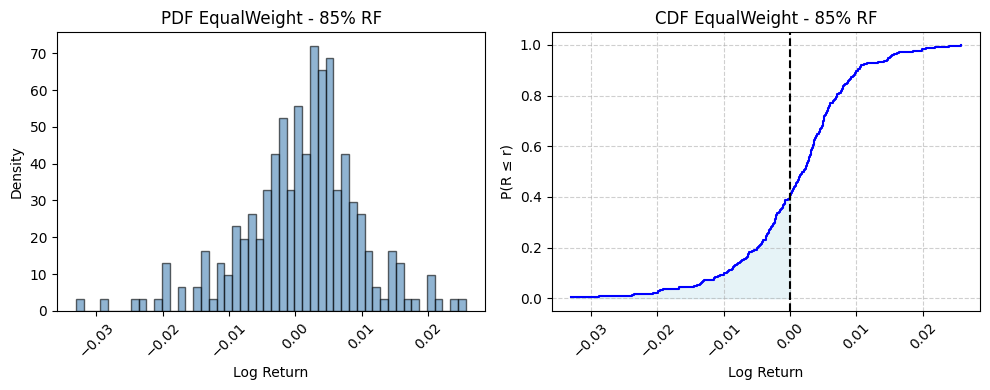

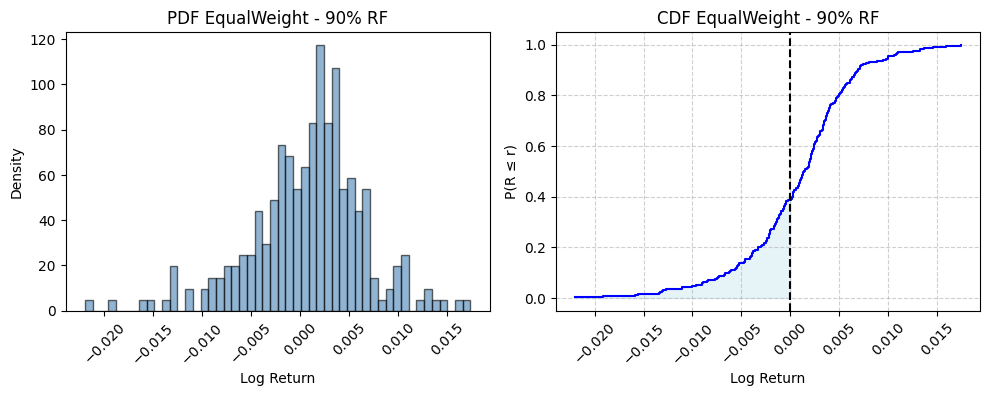

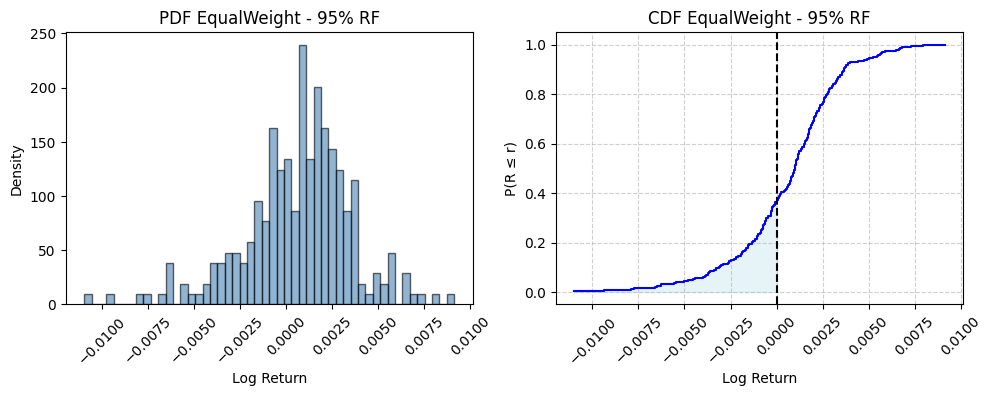

In [44]:

# Change paths here if necessary
returns_85 = pd.read_csv('portfolio_returns_85RF.csv', index_col=0)
returns_90 = pd.read_csv('portfolio_returns_90RF.csv', index_col=0)
returns_95 = pd.read_csv('portfolio_returns_95RF.csv', index_col=0)

# Column name for Equal Weight portfolio. Adjust if necessary.
equal_weight_col_name = "EqualWeight"  

# Generate PDF and CDF graphs for the 3 risk-free levels 
for rf, returns_df in zip([85, 90, 95], [returns_85, returns_90, returns_95]):
    eqw_returns = returns_df[equal_weight_col_name]
    title_pdf = f"PDF EqualWeight - {rf}% RF"
    title_cdf = f"CDF EqualWeight - {rf}% RF"
    plot_pdf_cdf(eqw_returns, title_pdf, title_cdf)

Repeats the **xi/Vega vs K** sensitivity analysis seen for the S&P 500 index, this time on the 85% RF EqualWeight portfolio (`log_ret` is reassigned to this series). The curves have the same qualitative shape seen previously but on a much smaller return scale, consistent with the low volatility of an 85% risk-free portfolio.

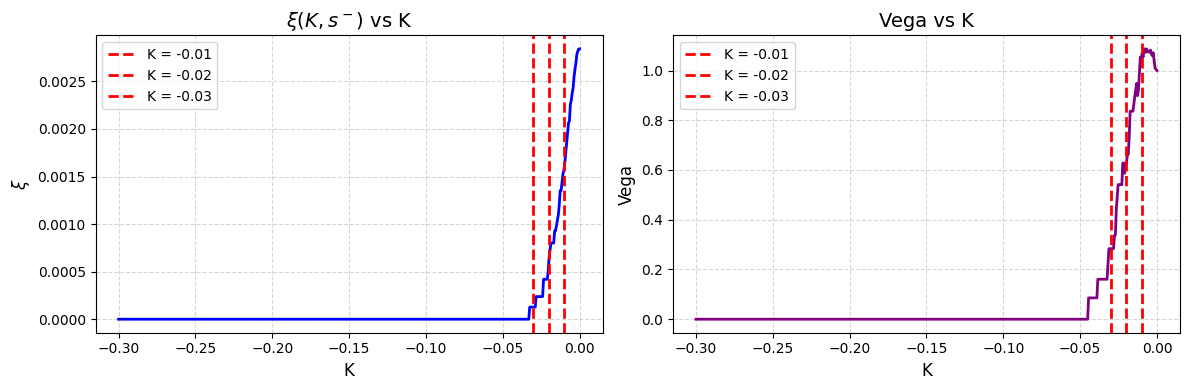

In [45]:
#############################################################################################
# ADDITIONAL GRAPHS FOR VEGA OF BARBELL PORTFOLIOS
#############################################################################################

log_ret = returns_85['EqualWeight'] # CHANGE COLUMN AND DF TO GET OTHER GRAPHS
# Data parameters
Omega = 0.0
Ks = np.linspace(-0.3, 0.0, 500)  # Range for K
K_current = log_ret.quantile(0.05)  # Fixed current K
Delta_s = 1e-3

# Lists to collect results
s_list, xi_list, vega_list = [], [], []

for Ki in Ks:
    s = s_minus(log_ret, Omega)  # fixed left semi-deviation relative to Omega
    lam = lambda_from_s_empirical(s, s_minus(log_ret, Omega))  # lambda calculated relative to fixed baseline
    xi = xi_K_on_baseline(log_ret, lam, Omega, Ki)
    V = vega_tail_baseline(log_ret, s, s_minus(log_ret, Omega), Omega, Ki, Delta_s)

    s_list.append(s)
    xi_list.append(xi)
    vega_list.append(V)

# Conversion to array for plot
xi_array = np.array(xi_list)
vega_array = np.array(vega_list)

K_1 = -0.01
K_2 = -0.02
K_3 = -0.03

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: ξ(K,s⁻) vs K
axs[0].plot(Ks, xi_array, color='blue', lw=2)
axs[0].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.01')
axs[0].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[0].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[0].set_title(r'$\xi(K,s^-)$ vs K', fontsize=14)
axs[0].set_xlabel('K', fontsize=12)
axs[0].set_ylabel(r'$\xi$', fontsize=12)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# Graph 2: Vega vs K
axs[1].plot(Ks, vega_array, color='purple', lw=2)
axs[1].axvline(K_1, color='red', linestyle='--', lw=2, label='K = -0.01')
axs[1].axvline(K_2, color='red', linestyle='--', lw=2, label='K = -0.02')
axs[1].axvline(K_3, color='red', linestyle='--', lw=2, label='K = -0.03')
axs[1].set_title('Vega vs K', fontsize=14)
axs[1].set_xlabel('K', fontsize=12)
axs[1].set_ylabel('Vega', fontsize=12)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Plots of `s-` and `lambda` as `s-` varies for the 85% RF EqualWeight portfolio — the same linearity check seen for the index, applied here to the barbell portfolio.

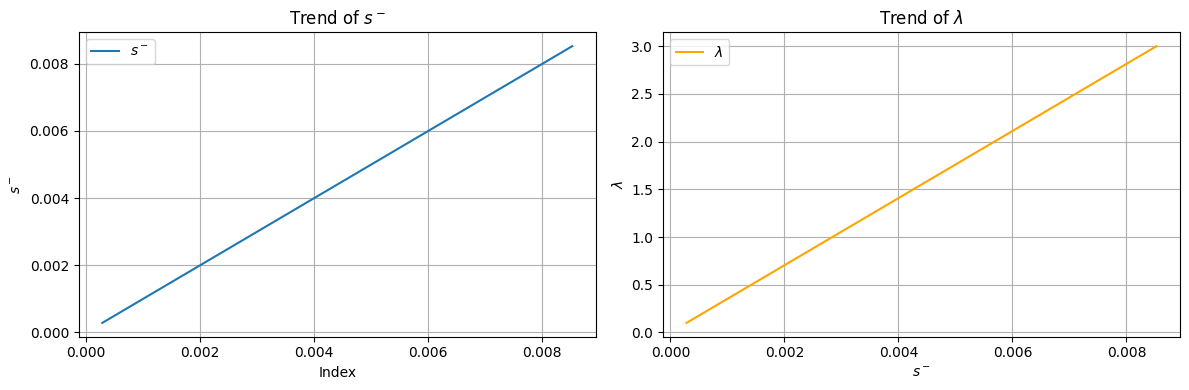

In [46]:
# Base parameters
Omega = 0.0
Delta_s = 1e-3
K = -0.01

# Reference left semi-deviation baseline
s_left = s_minus(log_ret, Omega)

# Variation of s^-
s_minus_vals = np.linspace(s_left * 0.1, s_left * 3, 500)

lambda_vals = []
xi_vals = []
vega_vals = []

for s_val in s_minus_vals:
    lam = lambda_from_s_empirical(s_val, s_left)  # Calculate lambda relative to baseline s_left
    lambda_vals.append(lam)

    xi = xi_K(log_ret, lam, Omega, K)
    xi_vals.append(xi)

    vega = vega_tail_baseline(log_ret, s_val, s_left, Omega, K, Delta_s)
    vega_vals.append(vega)

# Graph 1: s^- and lambda
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(s_minus_vals, s_minus_vals, label=r'$s^-$')
axs[0].set_title('Trend of $s^-$')
axs[0].set_xlabel('Index')
axs[0].set_ylabel(r'$s^-$')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(s_minus_vals, lambda_vals, color='orange', label=r'$\lambda$')
axs[1].set_title(r'Trend of $\lambda$')
axs[1].set_xlabel(r'$s^-$')
axs[1].set_ylabel(r'$\lambda$')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

Plot of `xi` vs `s-` for the same portfolio — the same increasing, concave shape observed previously for the index, confirming that the framework's structural relationship is independent of the underlying asset.

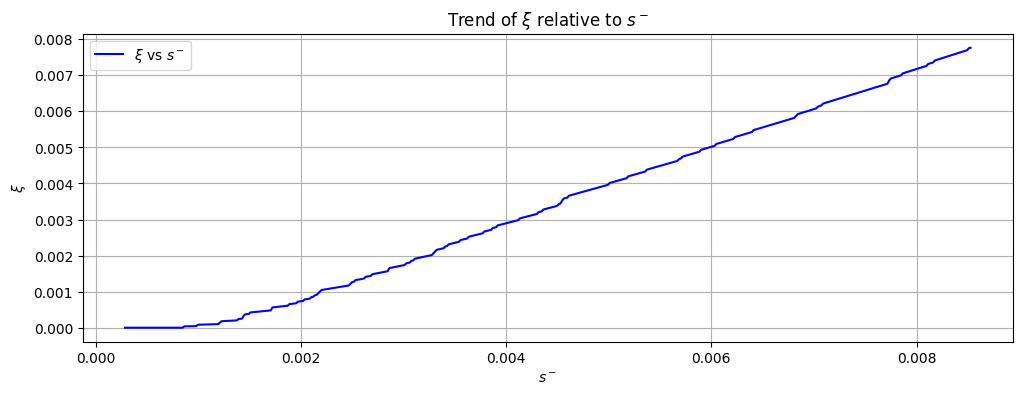

In [47]:
# Xi vs s^-
plt.figure(figsize=(12, 4))
plt.plot(s_minus_vals, xi_vals, label=r'$\xi$ vs $s^-$', color='blue')
plt.xlabel(r'$s^-$')
plt.ylabel(r'$\xi$')
plt.title(r'Trend of $\xi$ relative to $s^-$')
plt.legend()
plt.grid(True)
plt.show()

Single plot of **Vega vs s-** for the 85% RF EqualWeight portfolio, with a dashed line at the current value of `s-` — a more compact version (1 panel instead of the 2x2 grid seen for the index) of the same type of analysis.

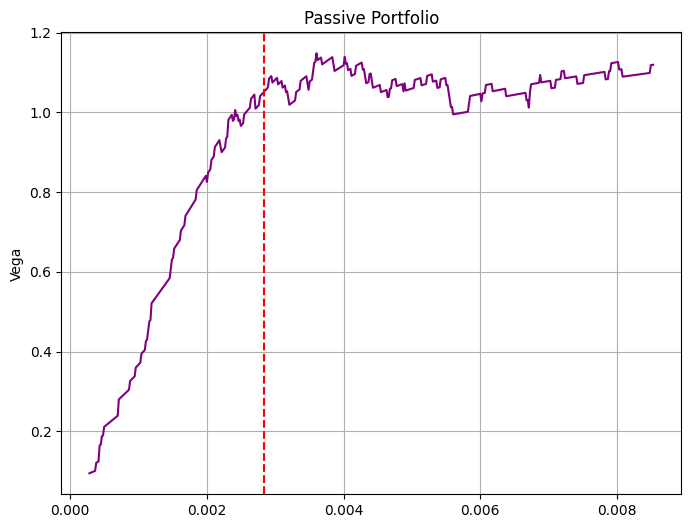

In [48]:
# vary s^-
Delta_s = 1e-3
# Calculate s^- for each distribution
s_orig = s_minus(log_ret, Omega)
K_orig = -0.01
s_minus_vals = np.linspace(s_orig * 0.1, s_orig * 3, 500)

vega_vals_orig = [vega_tail_baseline(log_ret, s_val, s_orig, Omega, K_orig, Delta_s) for s_val in s_minus_vals]

vega_color = 'purple'
line_color = 'red'

plt.figure(figsize=(8, 6))
plt.plot(s_minus_vals, vega_vals_orig, color=vega_color)
plt.axvline(s_orig, color=line_color, linestyle='--')
plt.title('Passive Portfolio')
plt.ylabel('Vega')
plt.grid(True)
plt.show()



Derivative of Vega with respect to `s-` for the same portfolio — a second-order fragility measure, single-panel version.

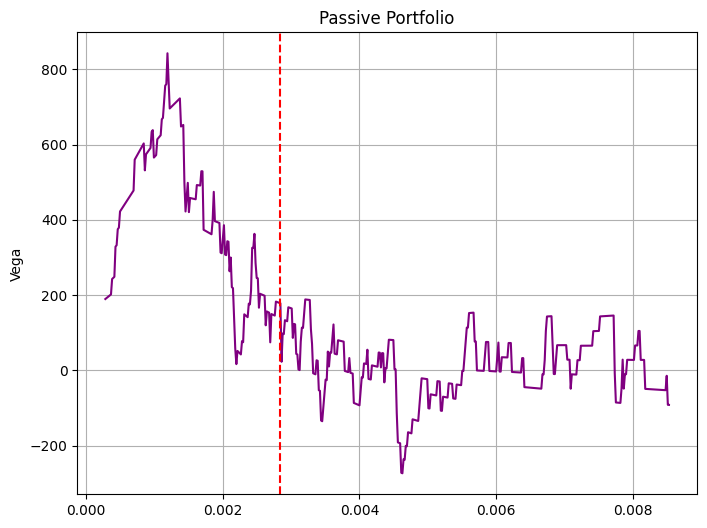

<Figure size 640x480 with 0 Axes>

In [49]:
Delta_s = 1e-3

# Specific s^- intervals for each case
s_minus_vals = np.linspace(s_orig * 0.1, s_orig * 3, 500)

# Calculation of Vega derivatives for each case
deriv_vega_vals_orig = [vega_derivative_s_minus(log_ret, s,s_orig, Omega, K_orig, Delta_s) for s in s_minus_vals]


vega_color = 'purple'
line_color = 'red'

plt.figure(figsize=(8, 6))
plt.plot(s_minus_vals, deriv_vega_vals_orig, color=vega_color)
plt.axvline(s_orig, color=line_color, linestyle='--')
plt.title('Passive Portfolio')
plt.ylabel('Vega')
plt.grid(True)
plt.show()


plt.tight_layout()
plt.show()



Final cell: derivative of Vega with respect to **K** for the 85% RF EqualWeight portfolio, with K=-0.02 as the reference — closes out the tail-sensitivity analysis applied to both the index and the barbell portfolios built in the thesis.

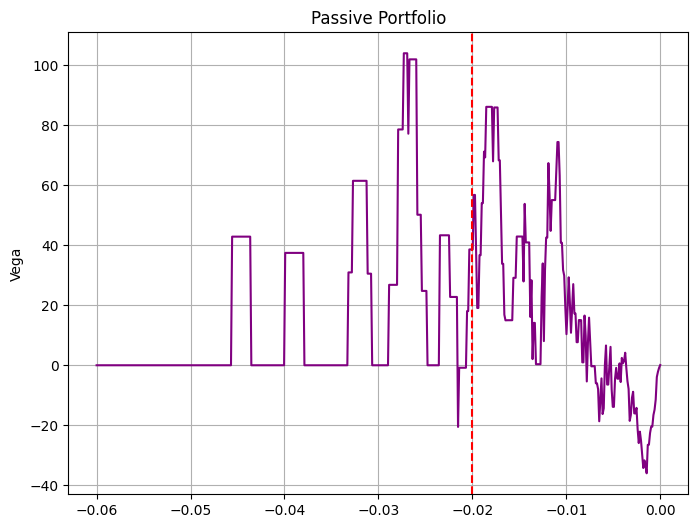

<Figure size 640x480 with 0 Axes>

In [50]:
Omega = 0.0
Delta_s = 1e-3
Delta_K = Delta_s
s_orig = s_minus(log_ret, Omega)
K = -0.02

# Variation intervals
K_vals = np.linspace(-0.06, 0, 500)

# Calculate Vega derivatives relative to K for original case
deriv_vega_K_vals_orig = [vega_derivative_k(log_ret, s_orig, Omega, k, Delta_K) for k in K_vals]

vega_color = 'purple'
line_color = 'red'

plt.figure(figsize=(8, 6))
plt.plot(K_vals, deriv_vega_K_vals_orig, color=vega_color)
plt.axvline(K, color=line_color, linestyle='--') # Corrected reference line to K
plt.title('Passive Portfolio')
plt.ylabel('Vega')
plt.grid(True)
plt.show()


plt.tight_layout()
plt.show()